In [2]:
import polars as pl
import matplotlib.pyplot as plt
from datetime import timedelta
import numpy as np

In [3]:
root_dir = '/home/hemanthm/Analysis_HEA/Timepix3_2025/GridPix_Dec2025/HEAstroPix/HVStability/'
filelist = ['hv_log_20260323_163930.csv', 'hv_log_20260323_154033.csv', 'hv_log_20260325_145049.csv', 'hv_log_20260327_121924.csv', 'hv_log_20260331_121644.csv', 'hv_log_20260401_140244.csv', 'hv_log_20260429_121427.csv']
df = pl.read_csv(root_dir + filelist[6])
RL_tag = 477#To display the load resistance in file names and pl 
df

Timestamp,Elapsed,ch0_setV,ch0_monV,ch0_setI,ch0_monI,ch0_status,ch1_setV,ch1_monV,ch1_setI,ch1_monI,ch1_status,ch2_setV,ch2_monV,ch2_setI,ch2_monI,ch2_status,ch3_setV,ch3_monV,ch3_setI,ch3_monI,ch3_status,ch4_setV,ch4_monV,ch4_setI,ch4_monI,ch4_status,ch5_setV,ch5_monV,ch5_setI,ch5_monI,ch5_status
str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64
"""2026-04-29 12:24:21""",593.81,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0
"""2026-04-29 12:24:22""",594.89,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0
"""2026-04-29 12:24:23""",595.65,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0
"""2026-04-29 12:24:24""",596.42,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0
"""2026-04-29 12:24:24""",597.22,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2026-04-29 17:24:53""",17993.24,0.0,1.0,100.0,0.0,0,0.0,1.0,100.0,0.0,0,0.0,2.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,3.0,100.0,0.0,0,0.0,3.0,100.0,0.0,0
"""2026-04-29 17:24:54""",17994.65,0.0,1.0,100.0,0.0,0,0.0,1.0,100.0,0.0,0,0.0,2.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,2.0,100.0,0.0,0,0.0,3.0,100.0,0.0,0
"""2026-04-29 17:24:56""",17996.11,0.0,1.0,100.0,0.0,0,0.0,1.0,100.0,0.0,0,0.0,2.0,100.0,0.0,0,0.0,0.0,100.0,0.0,0,0.0,2.0,100.0,0.0,0,0.0,3.0,100.0,0.0,0


In [4]:
N_CHANNELS = 6  # number of channels

# Which channels were powered on (i.e., status == 1 at least once)?
status_cols = [f"ch{i}_status" for i in range(N_CHANNELS)]
active_channels = [col for col in status_cols if df[col].sum() > 0]
print("Active channels:", active_channels)

#Find the minimum increment in monI for each channel
for ch in active_channels:
    monI_col = ch.replace("status", "monI")
    monI_values = df[monI_col].unique().sort()
    increments = monI_values.diff().drop_nulls()
    min_increment = increments.min()
    print(f"{ch}: min monI increment = {min_increment:.3f} uA")

#Range of monI for ch5
monI_ch5 = df["ch5_monI"]
print(f"ch5 monI range: {monI_ch5.min():.3f} uA to {monI_ch5.max():.3f} uA")

Active channels: ['ch0_status', 'ch1_status', 'ch2_status', 'ch3_status', 'ch4_status', 'ch5_status']
ch0_status: min monI increment = 0.100 uA
ch1_status: min monI increment = 0.100 uA
ch2_status: min monI increment = 0.100 uA
ch3_status: min monI increment = 0.100 uA
ch4_status: min monI increment = 0.100 uA
ch5_status: min monI increment = 0.100 uA
ch5 monI range: 0.000 uA to 19.200 uA


In [5]:
RAMP_RATE   = 10  # V/s
N_CHANNELS  = 6
SETTLE_TIME = 30  # s

# Parse Timestamp once on load
df = df.with_columns(
    pl.col("Timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S").alias("Timestamp")
)

def get_channel_stability(df: pl.DataFrame, ch: int) -> dict:
    setv_col   = f"ch{ch}_setV"
    monv_col   = f"ch{ch}_monV"
    monI_col   = f"ch{ch}_monI"
    status_col = f"ch{ch}_status"
    time_col   = "Timestamp"

    results = {}

    ch_df = df.filter(
        (pl.col(status_col) == 1) & (pl.col(setv_col) > 0)
    ).sort(time_col)

    if len(ch_df) == 0:
        print(f"ch{ch}: no active rows found")
        return results

    unique_setvs = sorted(ch_df[setv_col].unique().to_list())

    for setv in unique_setvs:
        seg = ch_df.filter(pl.col(setv_col) == setv)

        t_seg_start = seg[time_col][0]  # datetime
        prior       = ch_df.filter(pl.col(time_col) < t_seg_start)
        prev_setv   = prior[setv_col][-1] if len(prior) > 0 else 0.0

        ramp_time   = abs(setv - prev_setv) / RAMP_RATE          # seconds (float)
        skip_time   = ramp_time + SETTLE_TIME                     # seconds (float)

        # Offset t_seg_start by skip_time using timedelta
        t_settled   = t_seg_start + timedelta(seconds=skip_time)

        settled = seg.filter(pl.col(time_col) >= t_settled)

        if len(settled) == 0:
            print(f"  ch{ch} @ {setv}V: no settled data "
                  f"(ramp={ramp_time:.1f}s + settle={SETTLE_TIME}s = {skip_time:.1f}s skipped, "
                  f"only {len(seg)} rows)")
            continue

        hv   = settled[monv_col]
        curr = settled[monI_col]

        results[setv] = {
            "mean":         hv.mean(),
            "std":          hv.std(),
            "min":          hv.min(),
            "max":          hv.max(),
            "range":        hv.max() - hv.min(),
            "offset":       hv.mean() - setv,
            "hv_settled":   hv,
            "curr_settled": curr,
            "curr_mean":    curr.mean(),
            "curr_std":     curr.std(),
            "curr_range":   curr.max() - curr.min(),
            "skip_time":    round(skip_time, 1),
            "t_settled":    t_settled,      # store for lightcurve shading
            "t_start":      t_seg_start,    # store for lightcurve shading
        }

    return results

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

#Make font times new roman
plt.rcParams["font.family"] = "Times New Roman"

def plot_stability_by_setv(stability: dict, n_channels: int = N_CHANNELS):
    """
    One figure per unique set voltage.
    Each figure has one subplot per channel that was active at that setV.
    Shows voltage distribution histogram + current stats in annotation.
    """
    # Collect all unique setVs across all channels
    all_setvs = sorted({
        setv
        for ch_stats in stability.values()
        for setv in ch_stats.keys()
    })

    for setv in all_setvs:
        # Which channels have data at this setV?
        active_chs = [
            f"ch{i}" for i in range(n_channels)
            if f"ch{i}" in stability and setv in stability[f"ch{i}"]
        ]
        if not active_chs:
            continue

        ncols = min(3, len(active_chs))
        nrows = int(np.ceil(len(active_chs) / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5 * ncols, 4 * nrows),
                                 squeeze=False)
        fig.suptitle(f"HV Stability — Set Voltage: {setv:.0f} V", fontsize=14, fontweight="normal")

        for idx, ch in enumerate(active_chs):
            ax = axes[idx // ncols][idx % ncols]
            stats = stability[ch][setv]

            hv   = stats["hv_settled"]    # store raw settled Series (see note below)
            curr = stats["curr_settled"]  # store raw settled current Series

            # Histogram of monitored voltage
            ax.hist(hv.to_numpy(), bins=30, color="steelblue", edgecolor="white", alpha=0.85)
            ax.set_yscale("log")
            #sns.histplot(hv.to_numpy(), bins=30, kde=True, color="steelblue", edgecolor="white", ax=ax, alpha=0.5)
            ax.axvline(stats["mean"], color="red",    linestyle="--", linewidth=1.2, label=f'mean={stats["mean"]:.3f}V')
            ax.axvline(setv,         color="orange",  linestyle=":",  linewidth=1.2, label=f'setV={setv:.1f}V')

            # Annotation box: voltage + current stats
            textstr = (
                f"V mean:  {stats['mean']:.4f} V\n"
                f"V std:   {stats['std']:.4f} V\n"
                f"V range: {stats['range']:.4f} V\n"
                f"V offset:{stats['offset']:+.4f} V\n"
                f"─────────────────\n"
                f"I mean:  {stats['curr_mean']:.4f} µA\n"
                f"I std:   {stats['curr_std']:.4f} µA\n"
                f"I range: {stats['curr_range']:.4f} µA"
            )
            ax.text(0.97, 0.97, textstr,
                    transform=ax.transAxes,
                    fontsize=8, verticalalignment="top", horizontalalignment="right",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.8),
                    fontfamily="monospace")

            ax.set_title(ch, fontsize=11)
            ax.set_xlabel("Monitored Voltage (V)")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8, loc="upper left")

        # Hide unused subplots
        for idx in range(len(active_chs), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)

        plt.tight_layout()
        plt.savefig(f"{root_dir}HVStabilityDist_setV{setv:.0f}V.png", dpi=150, bbox_inches="tight")
        plt.show()

# --- Stability loop ---
stability = {}
for i in range(N_CHANNELS):
    ch_stats = get_channel_stability(df, i)
    if ch_stats:
        stability[f"ch{i}"] = ch_stats

#plot_stability_by_setv(stability)

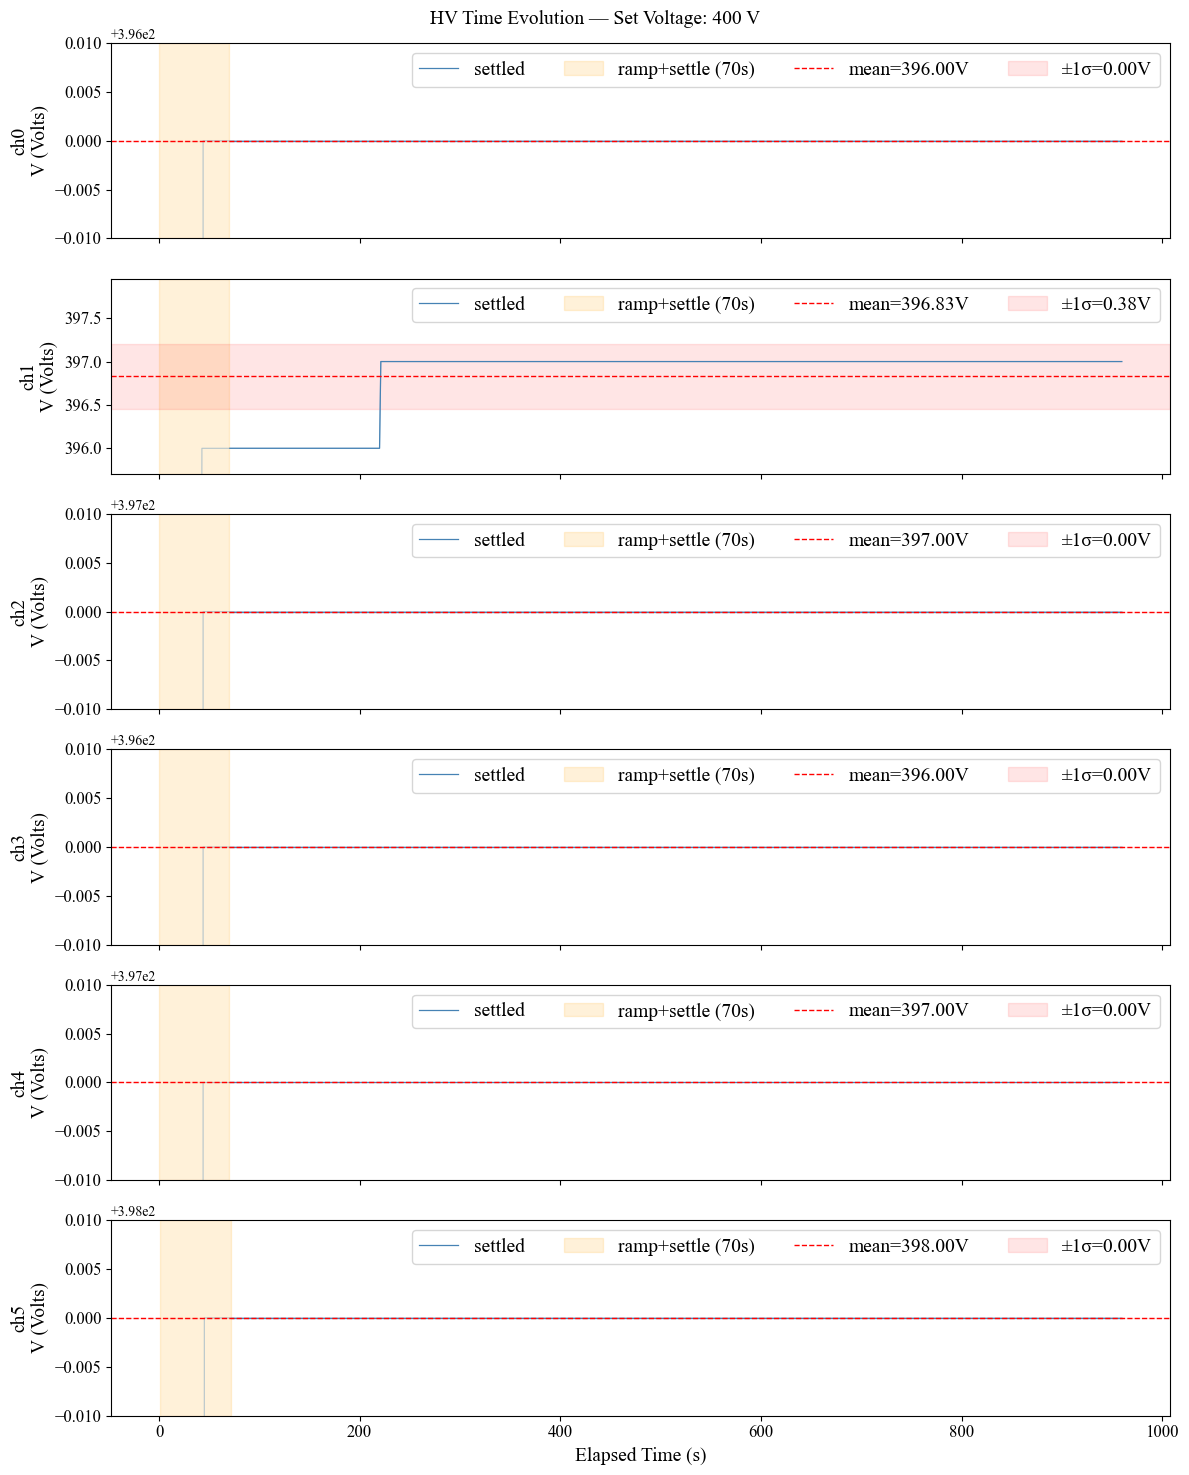

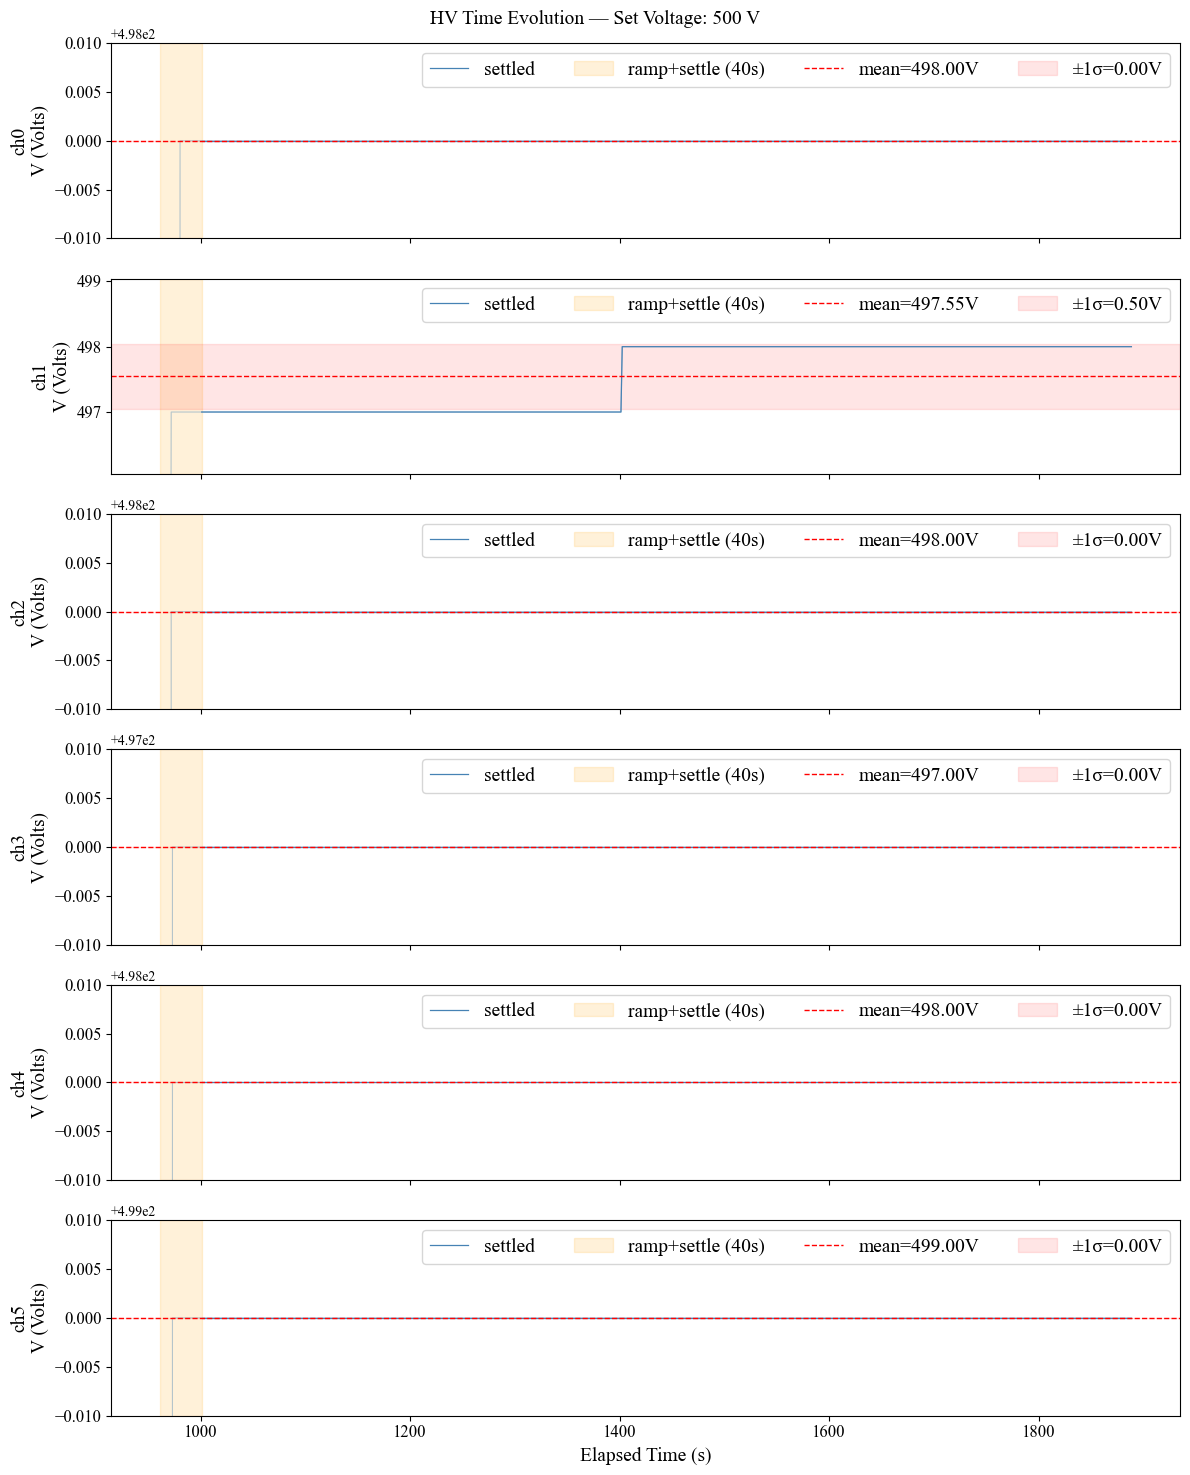

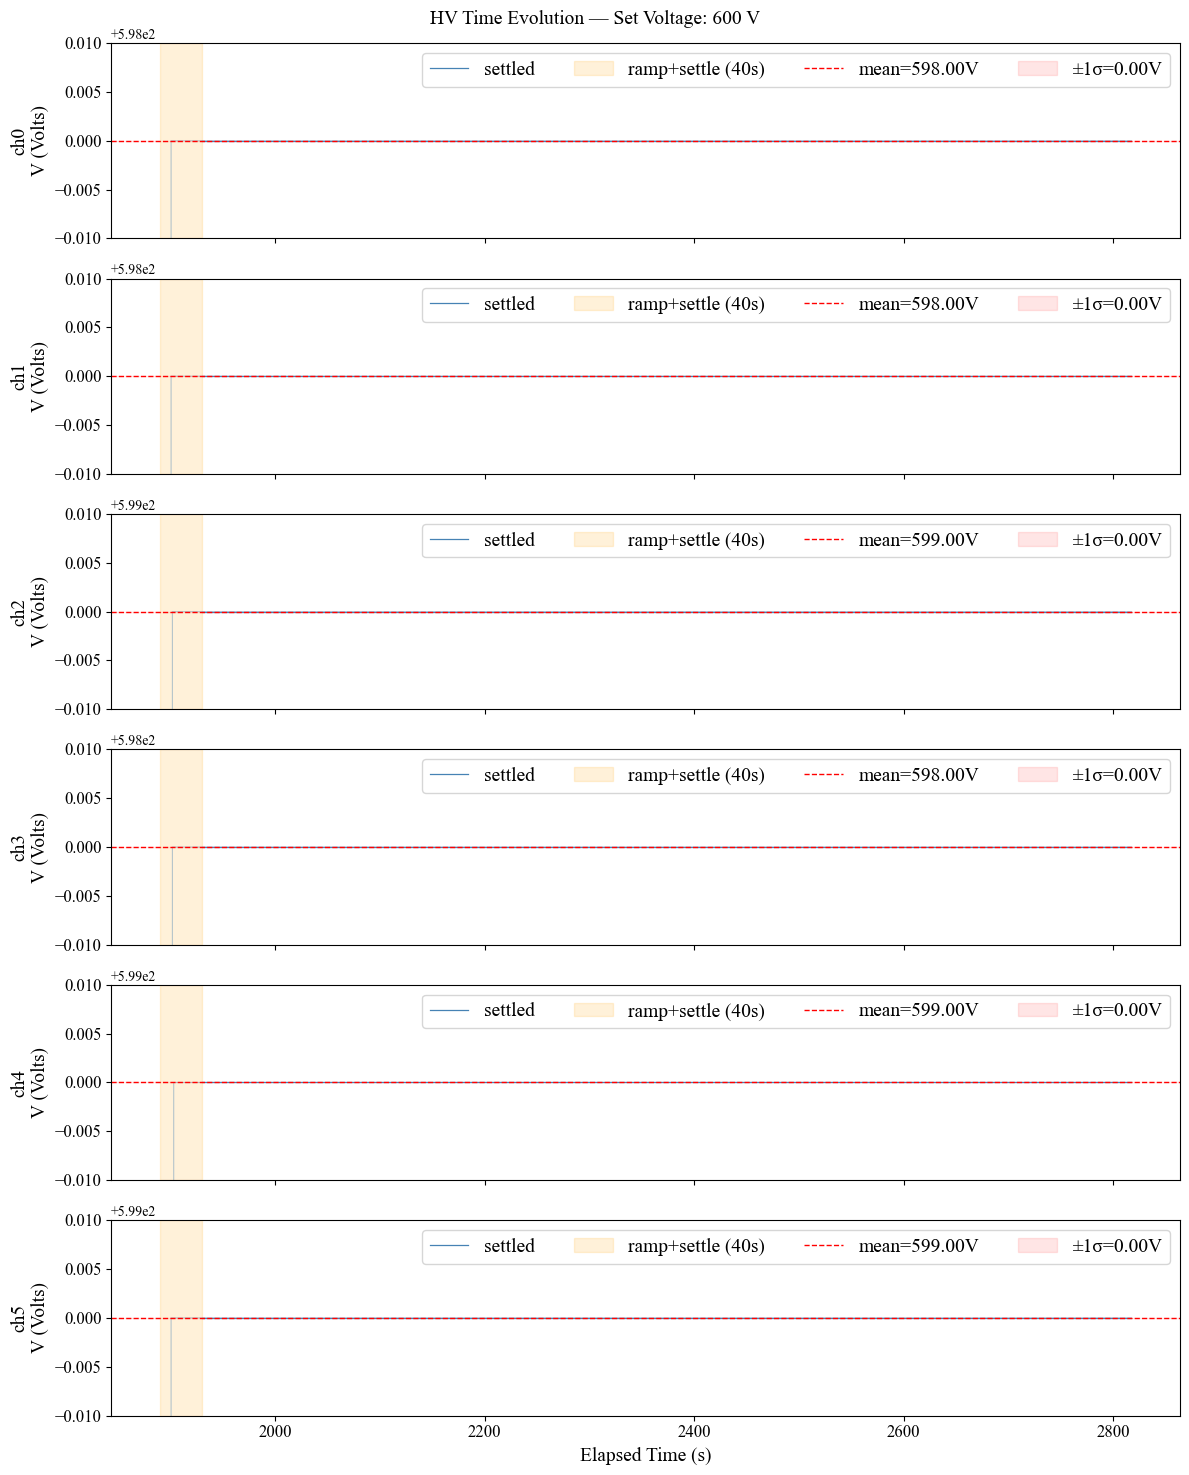

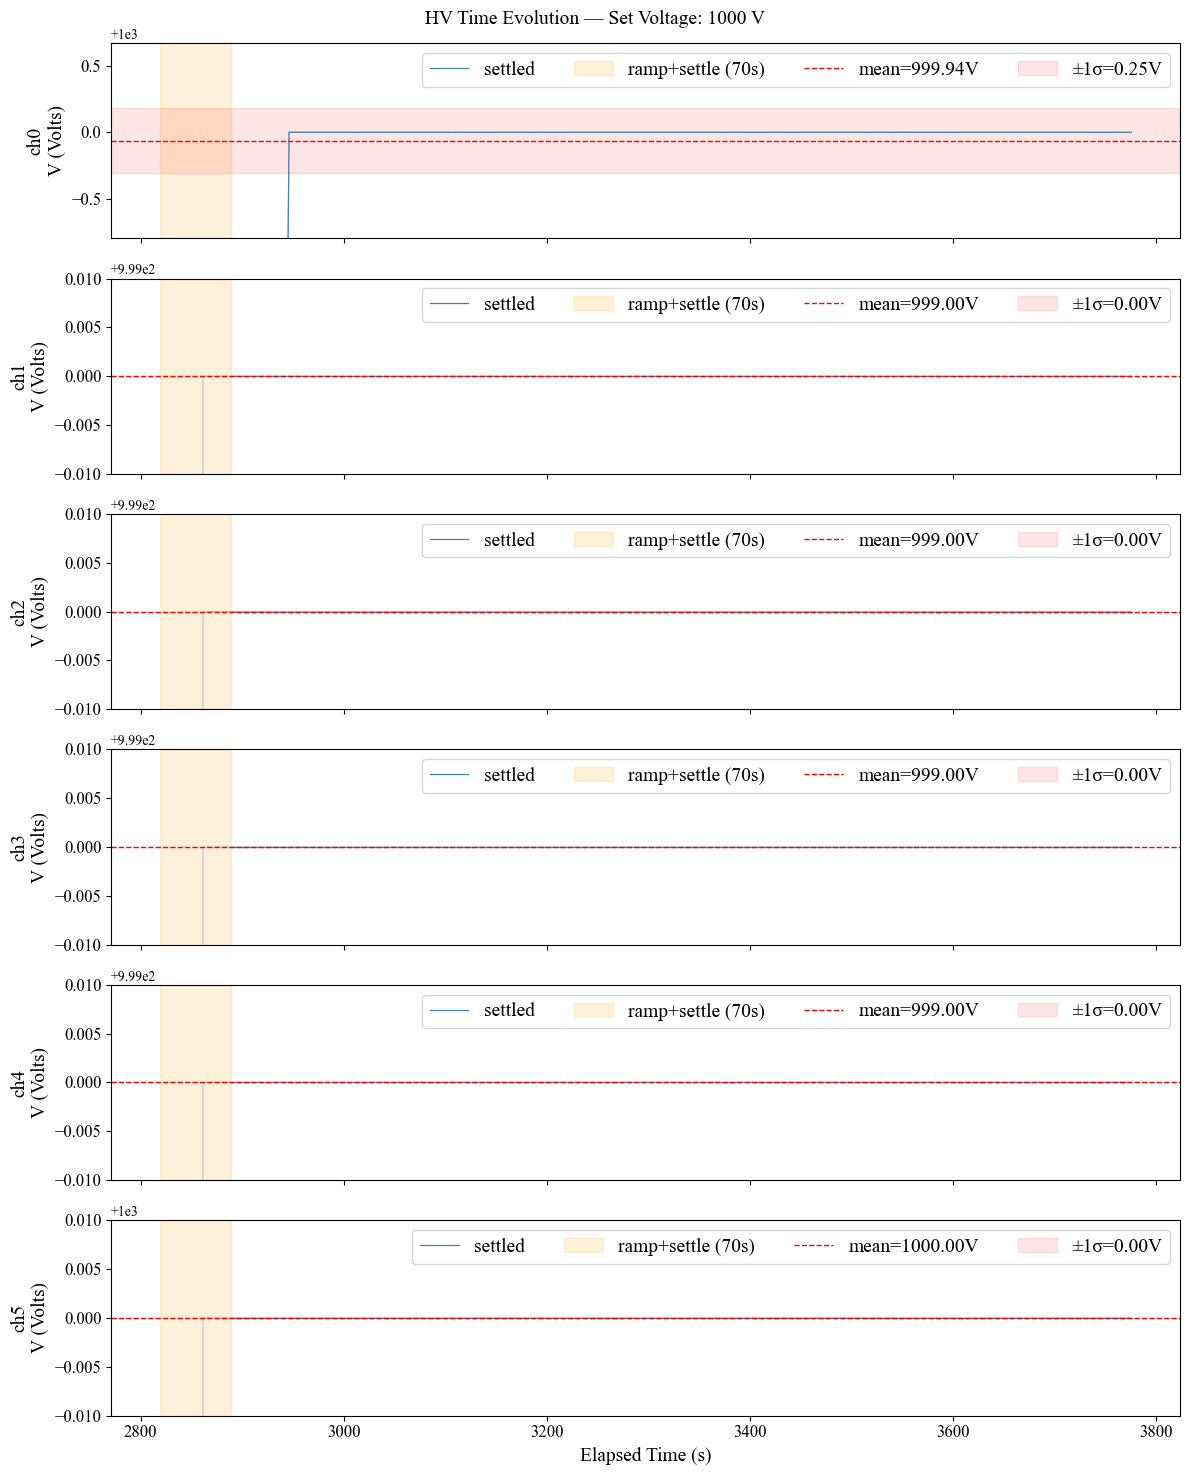

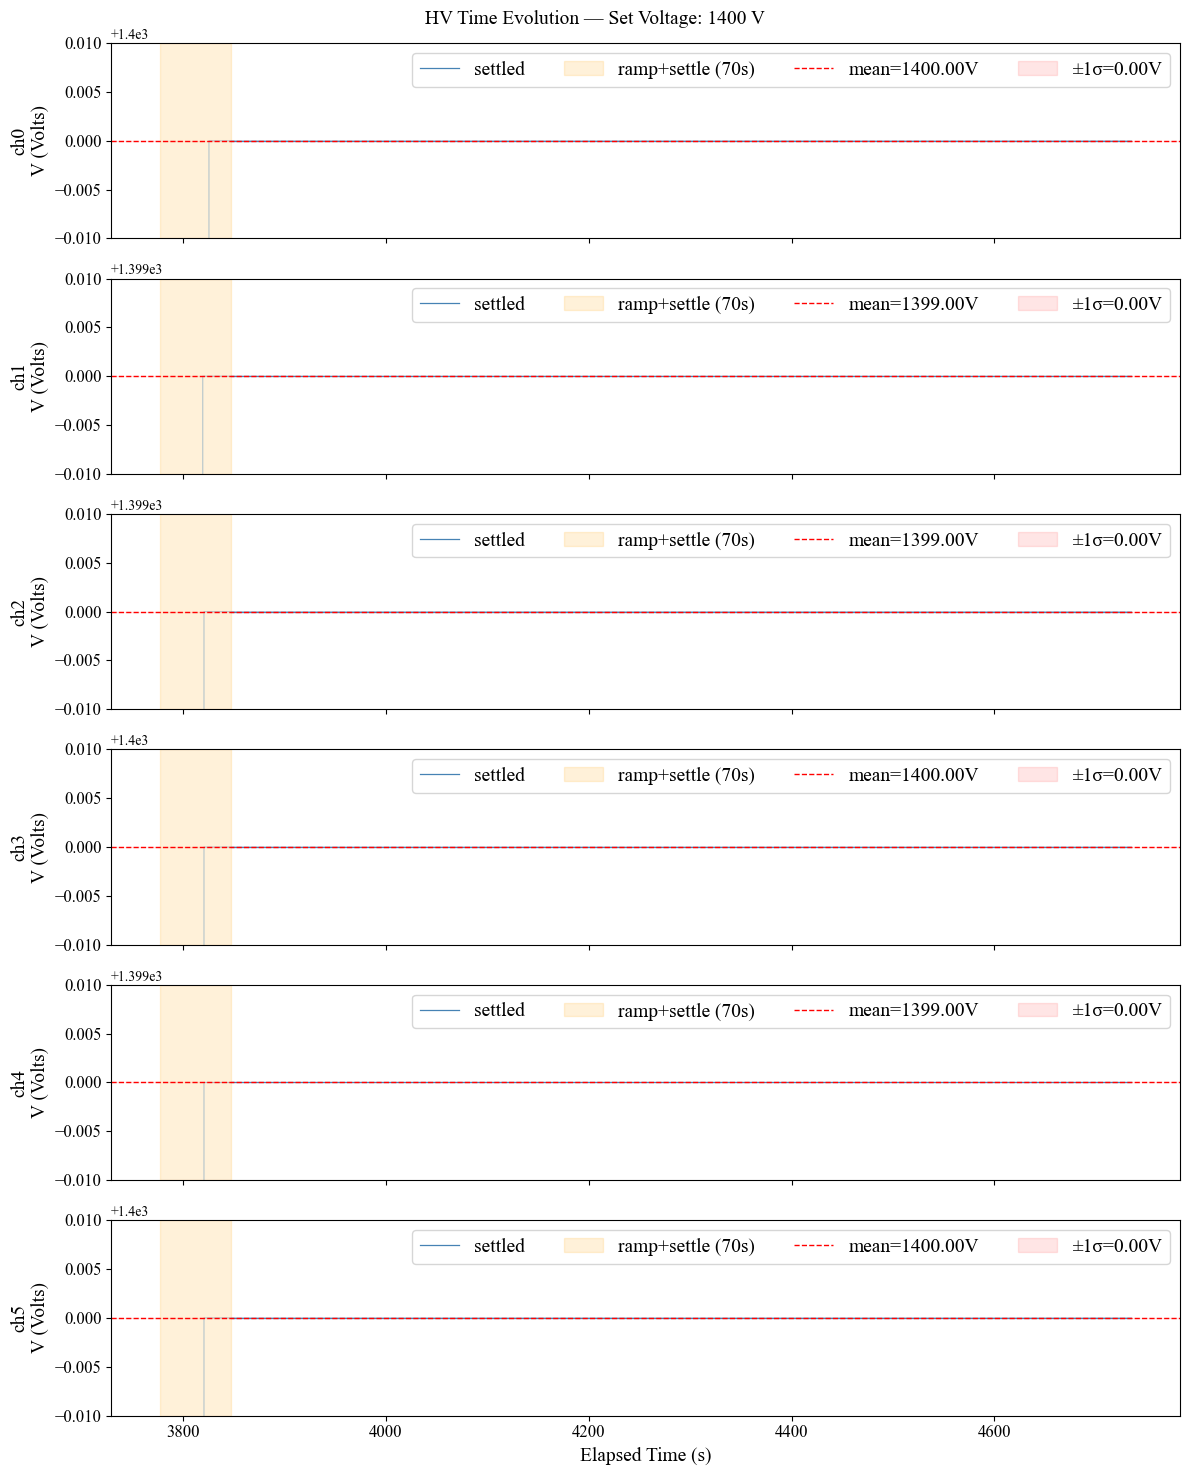

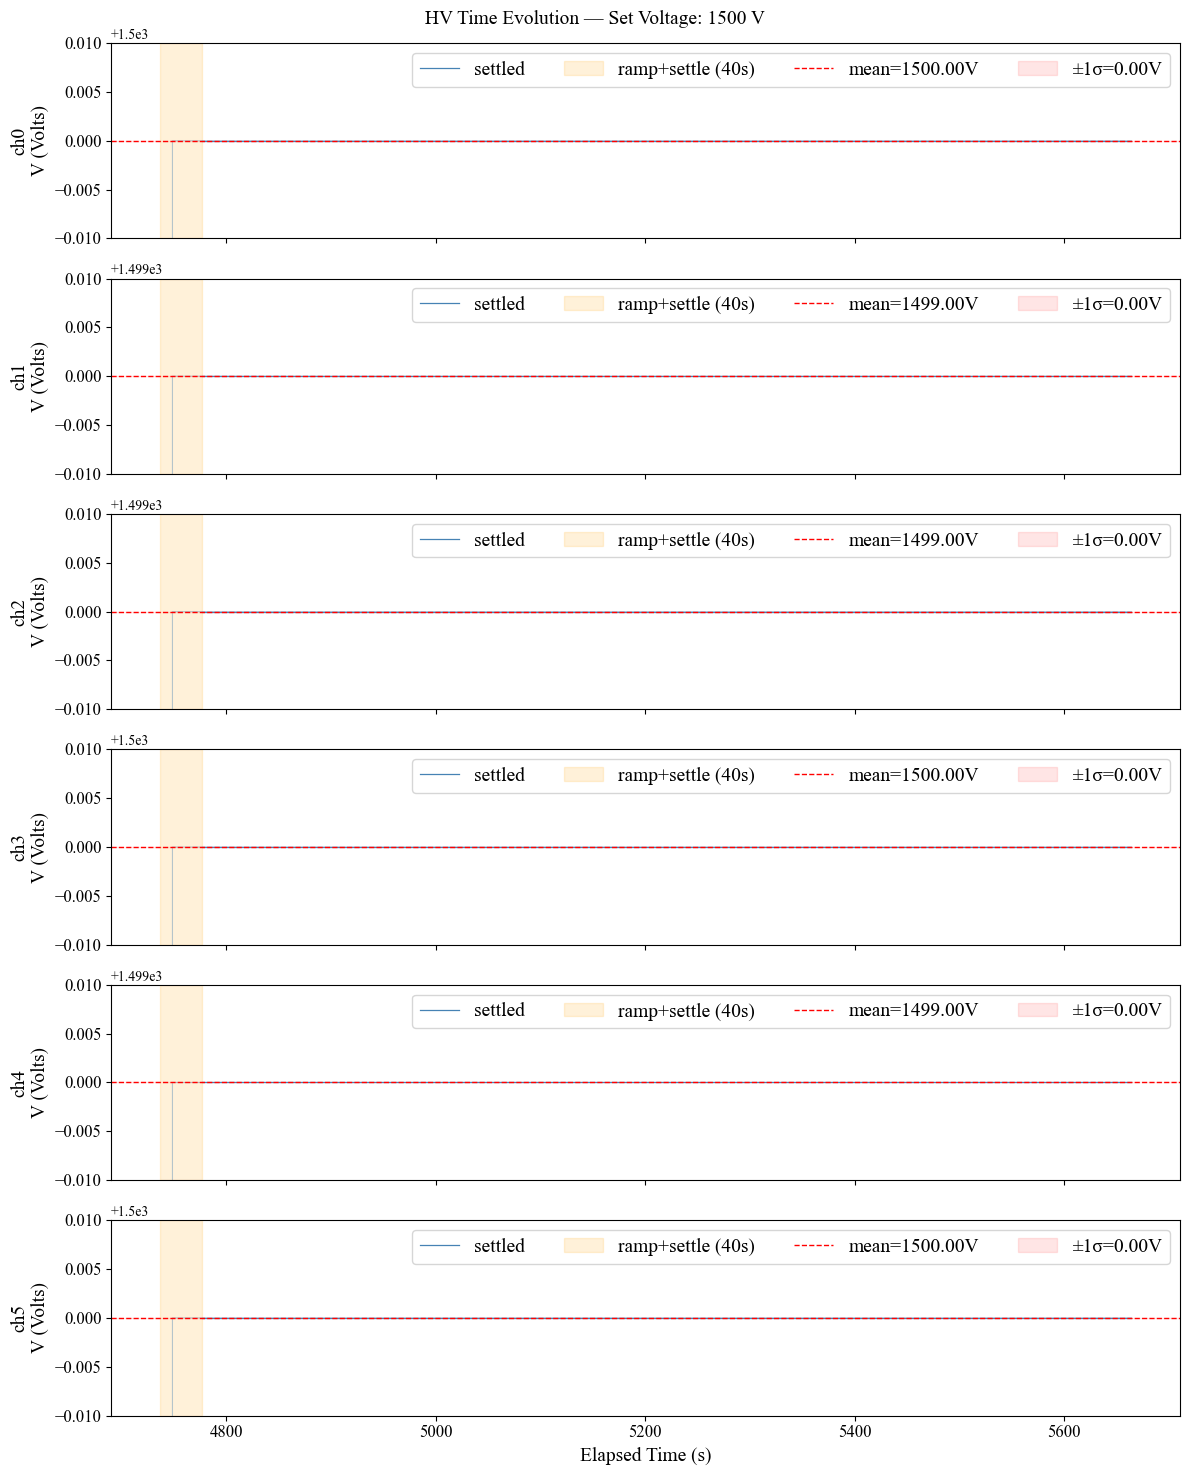

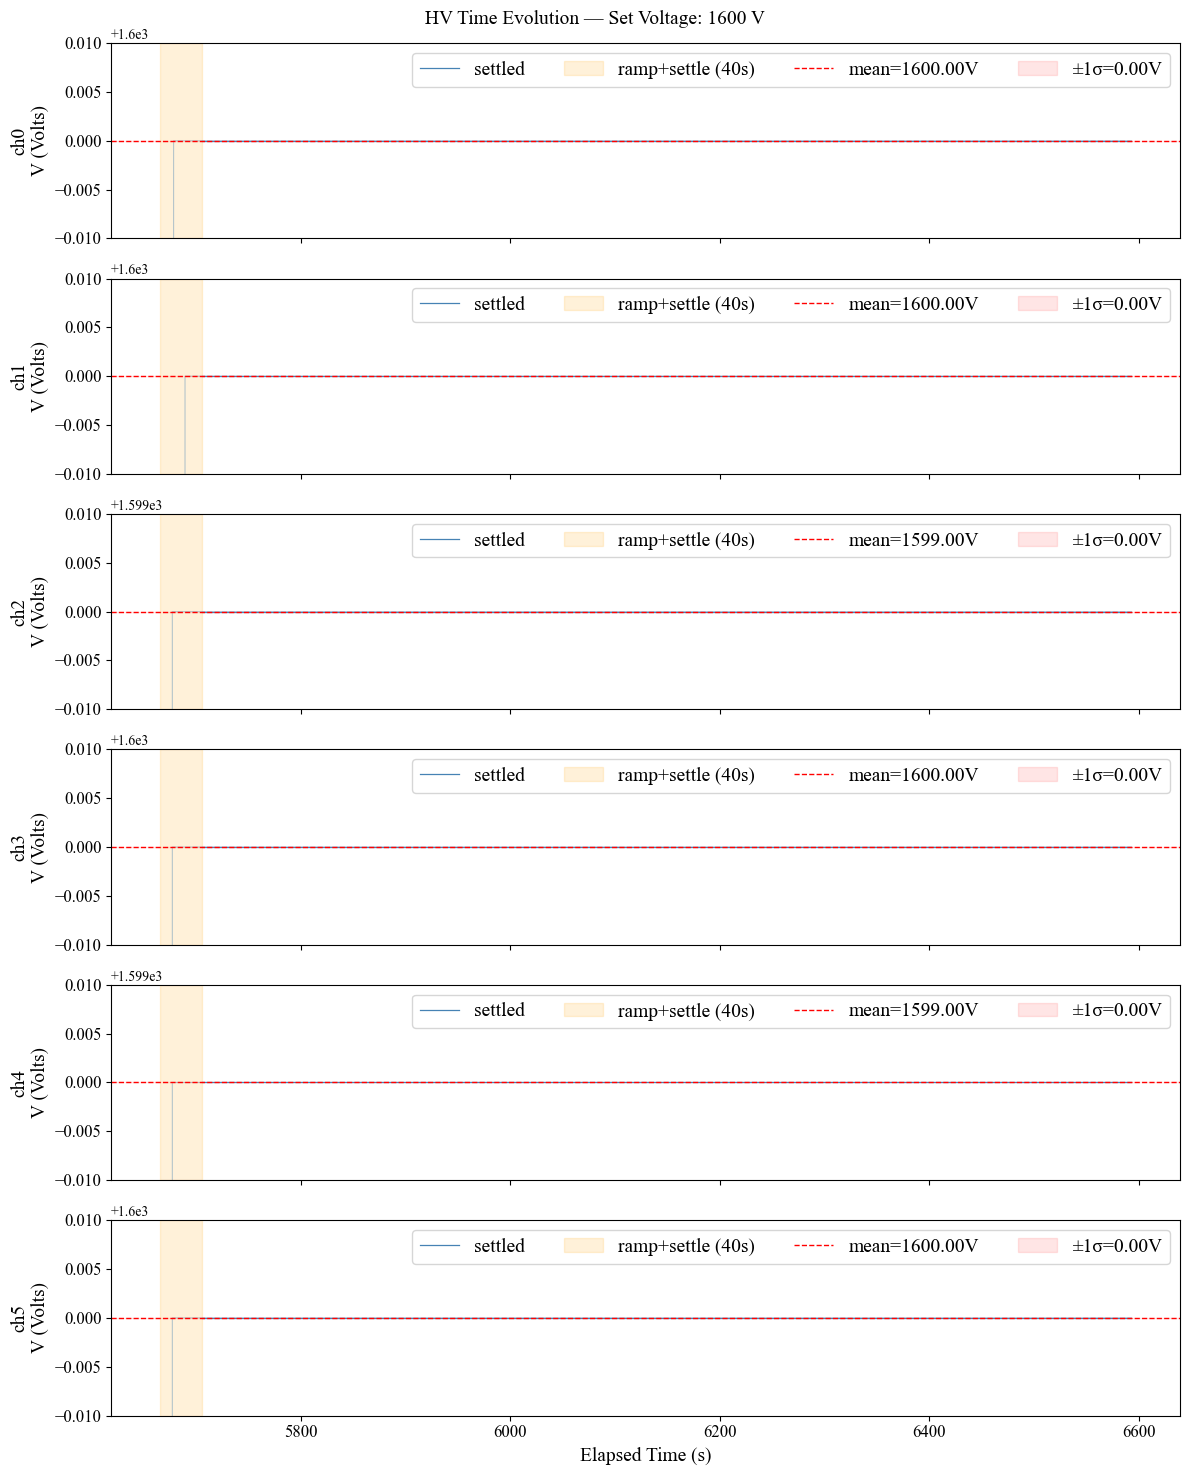

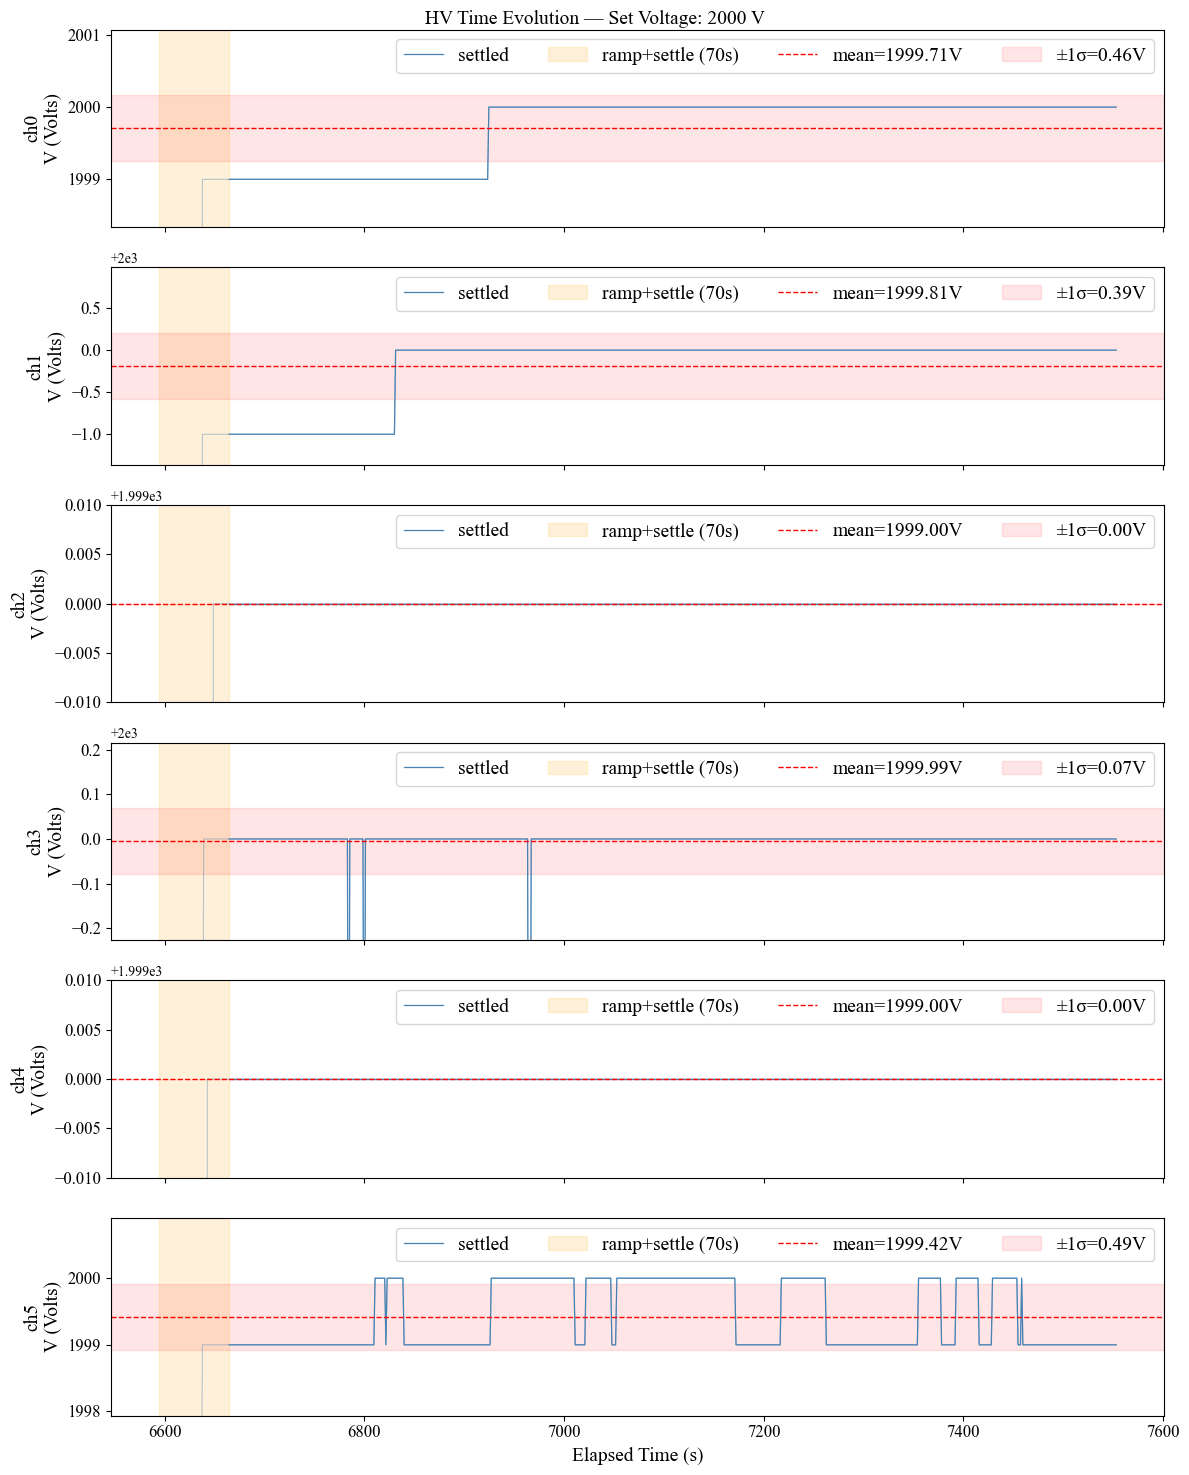

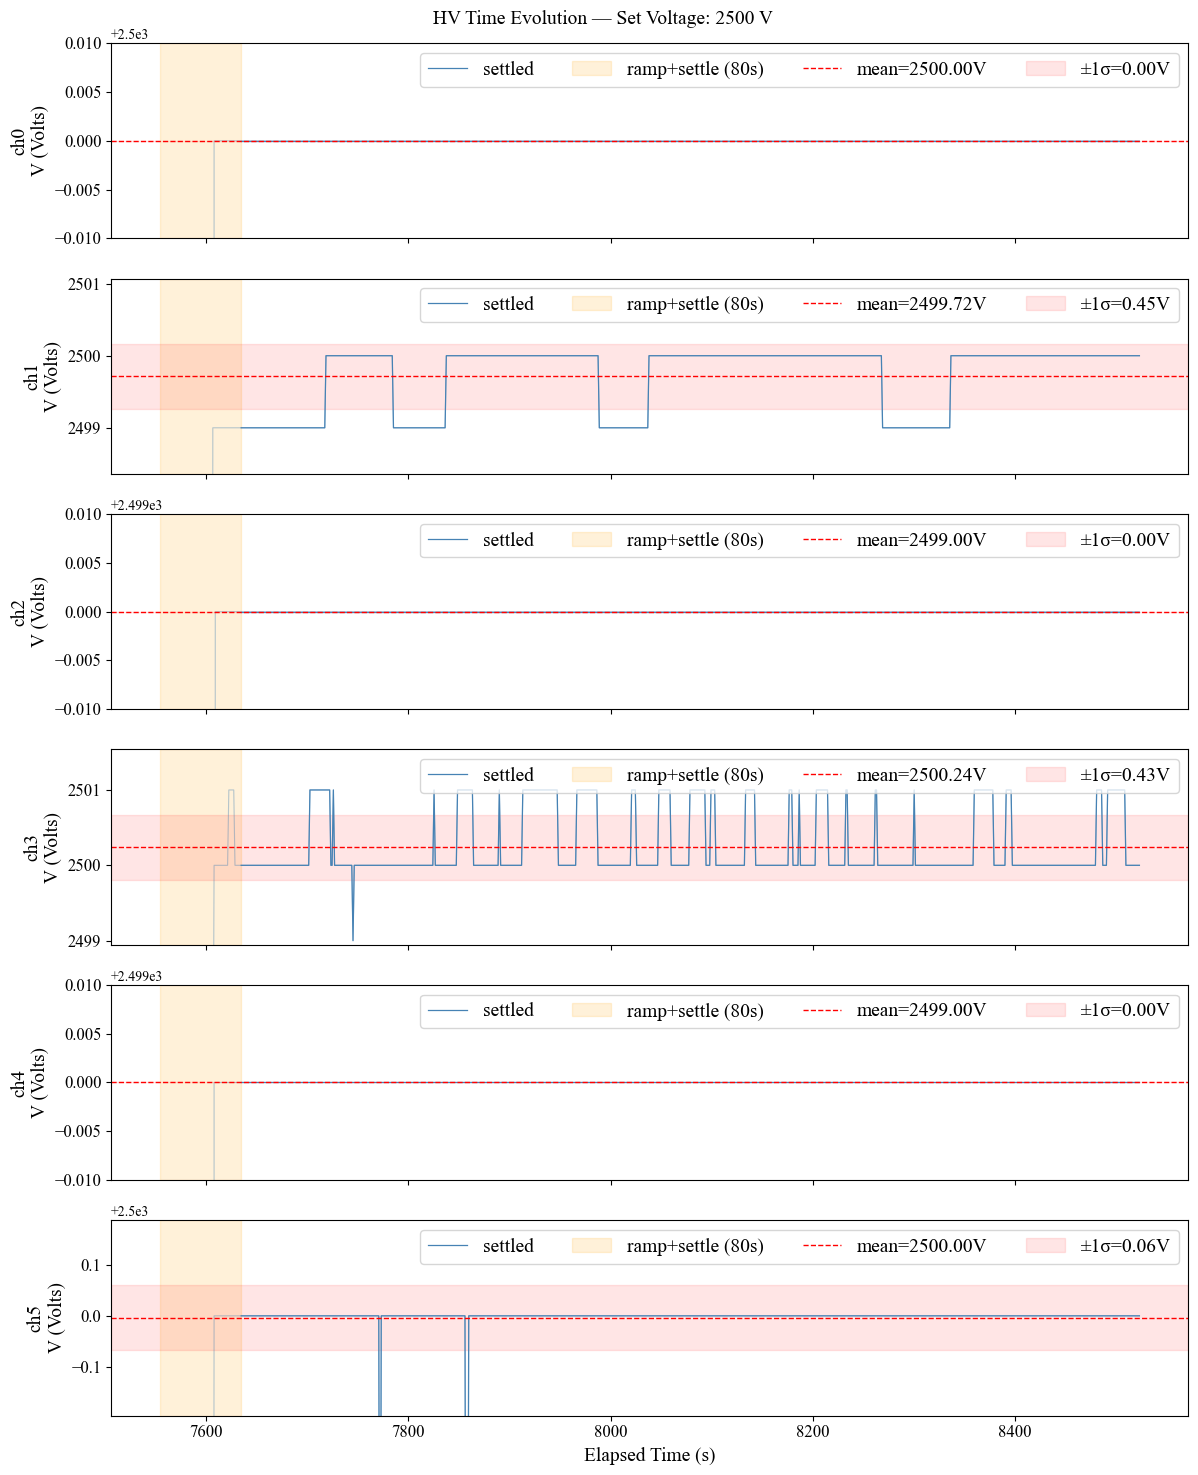

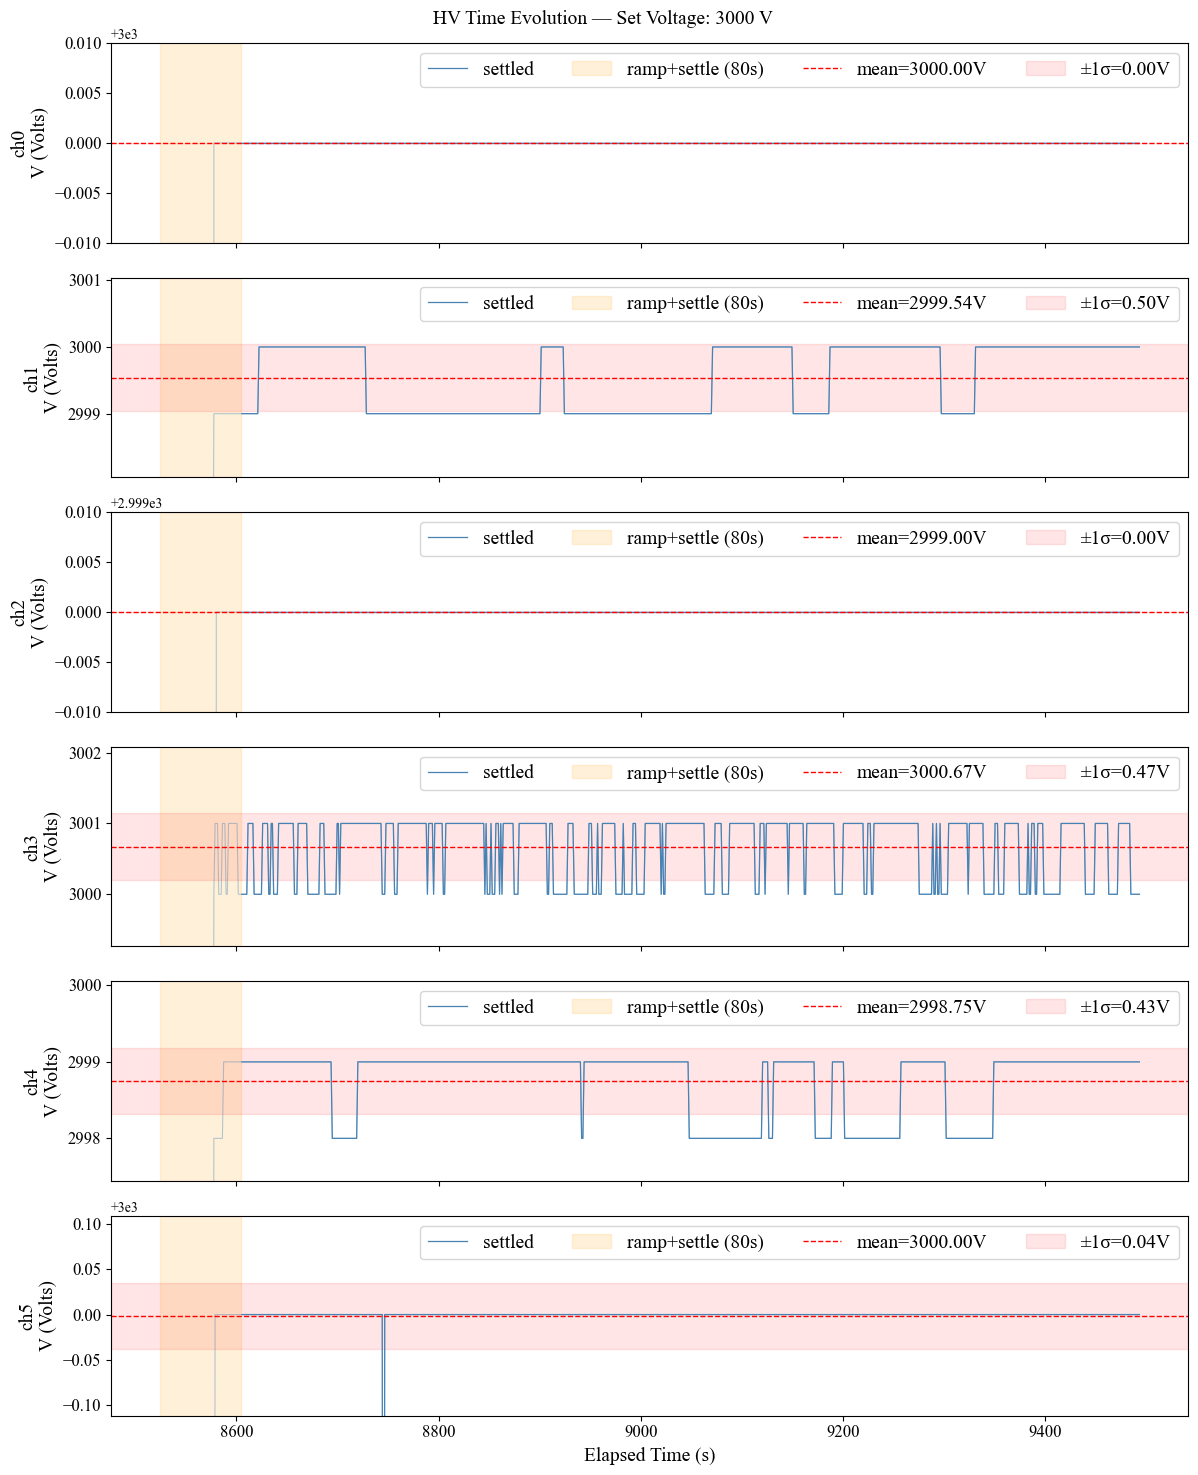

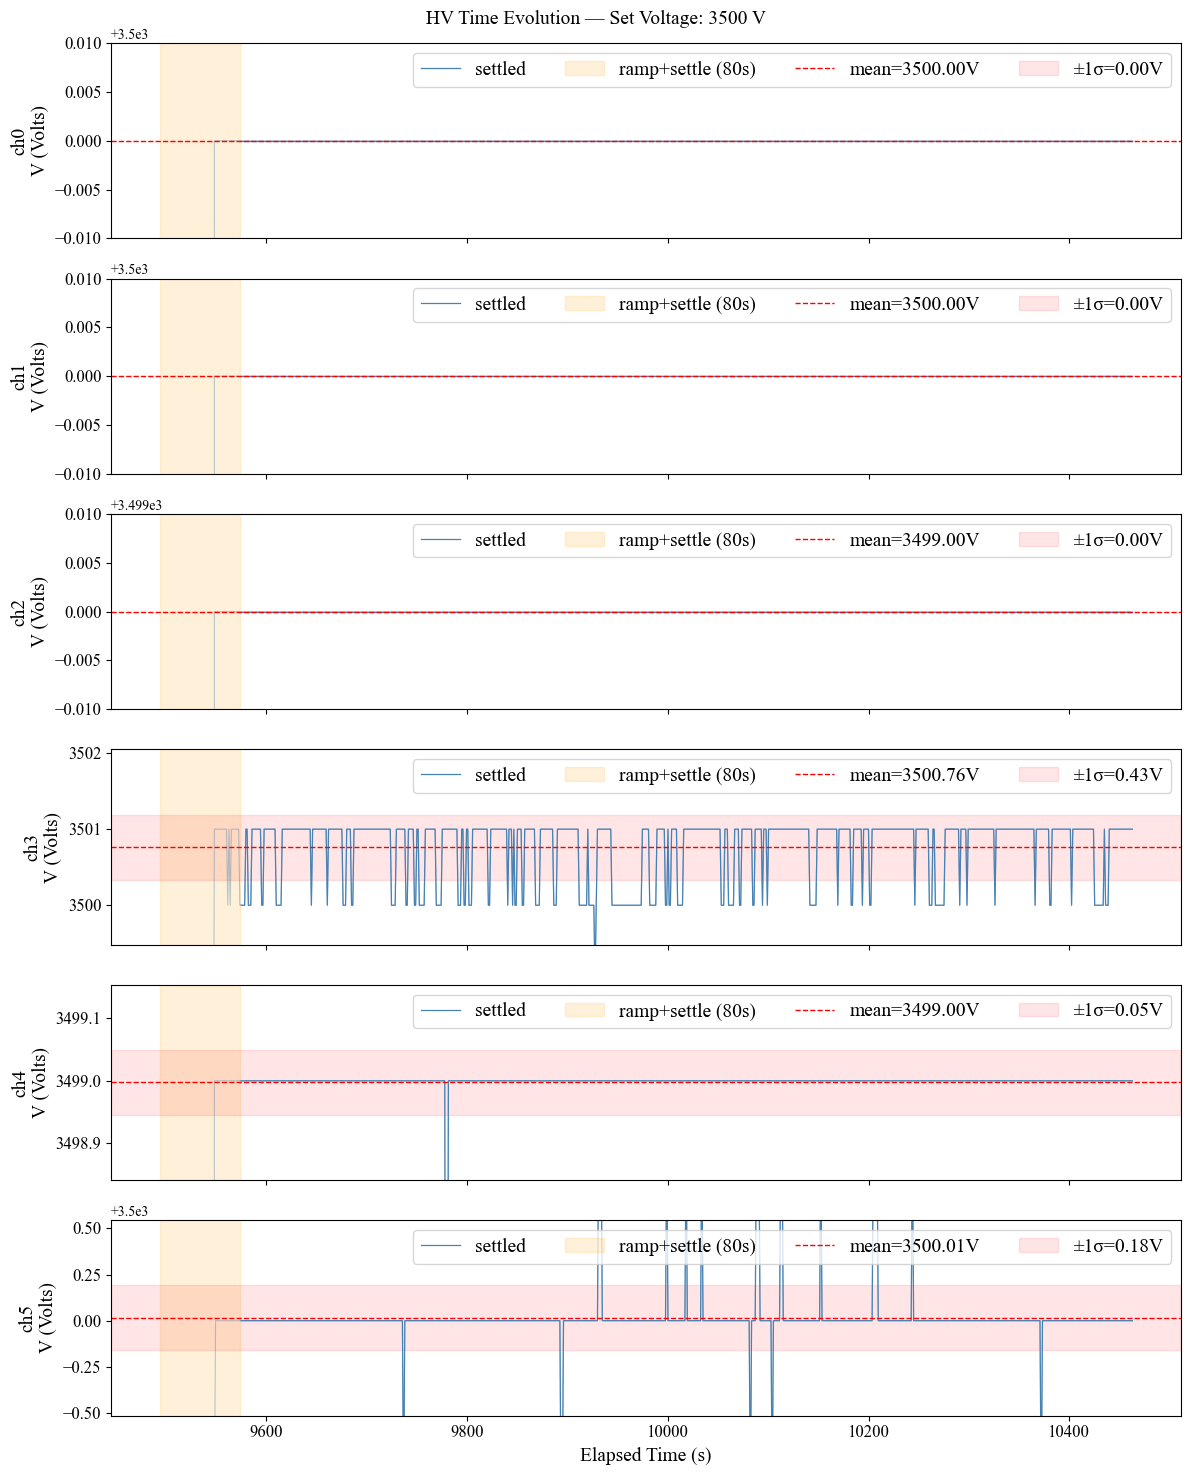

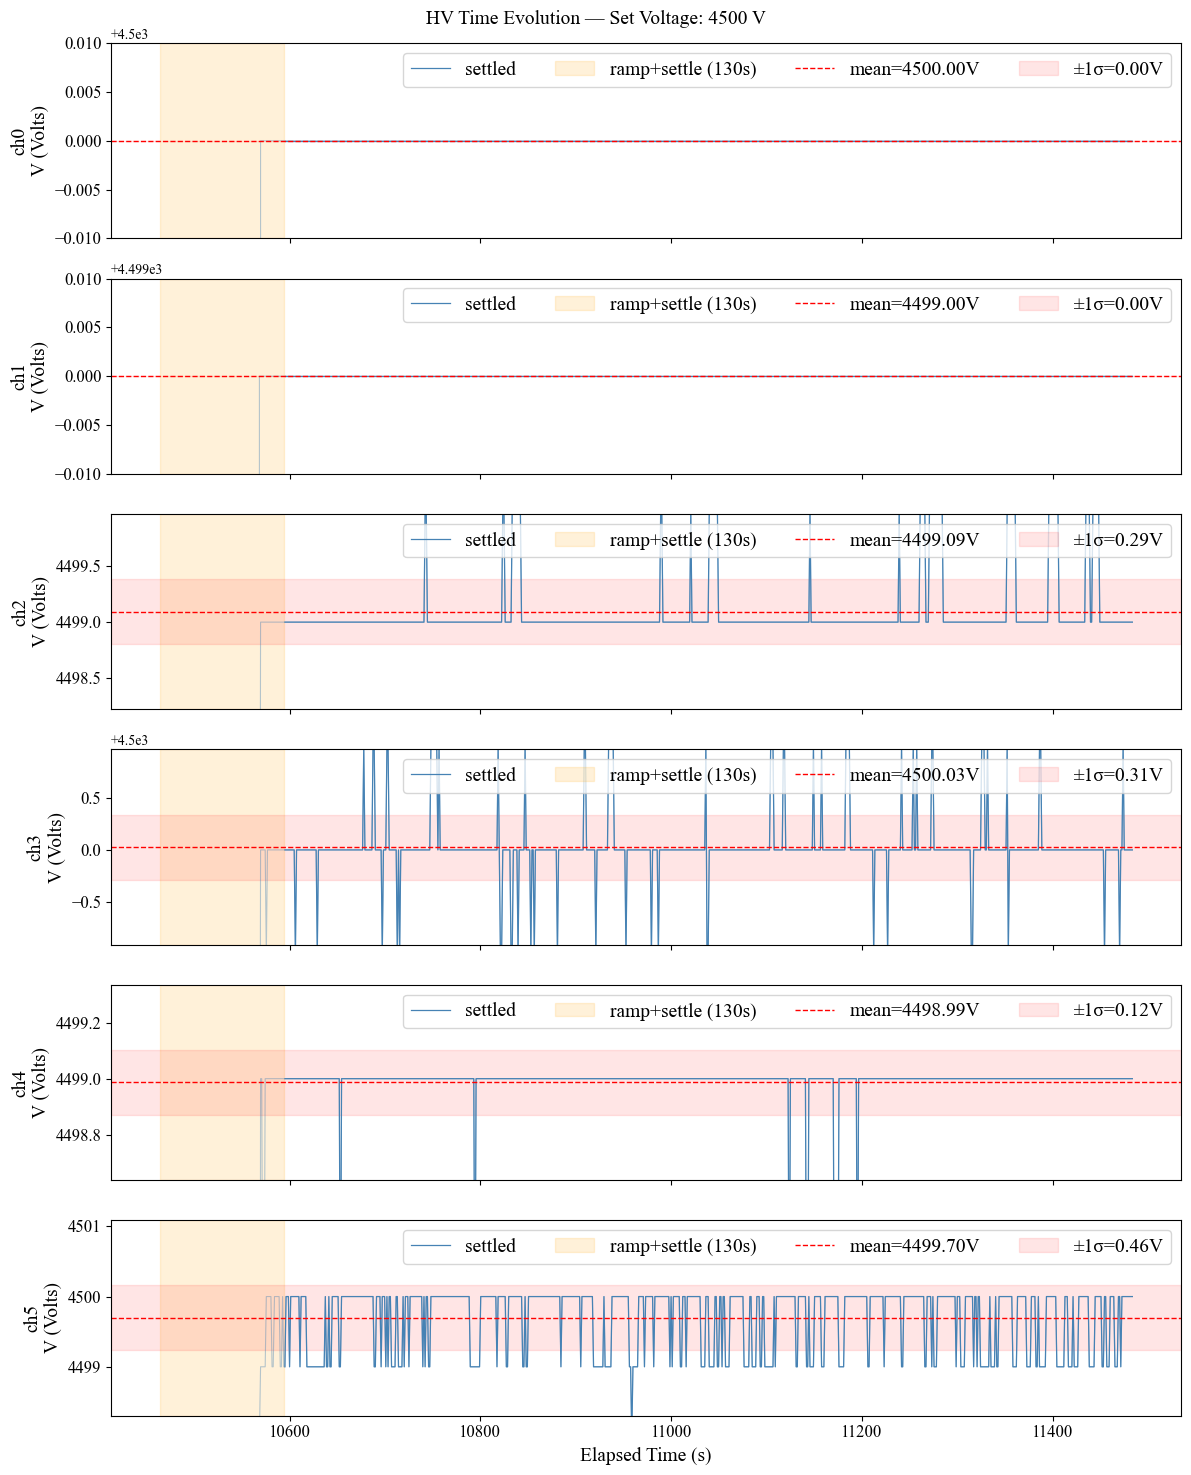

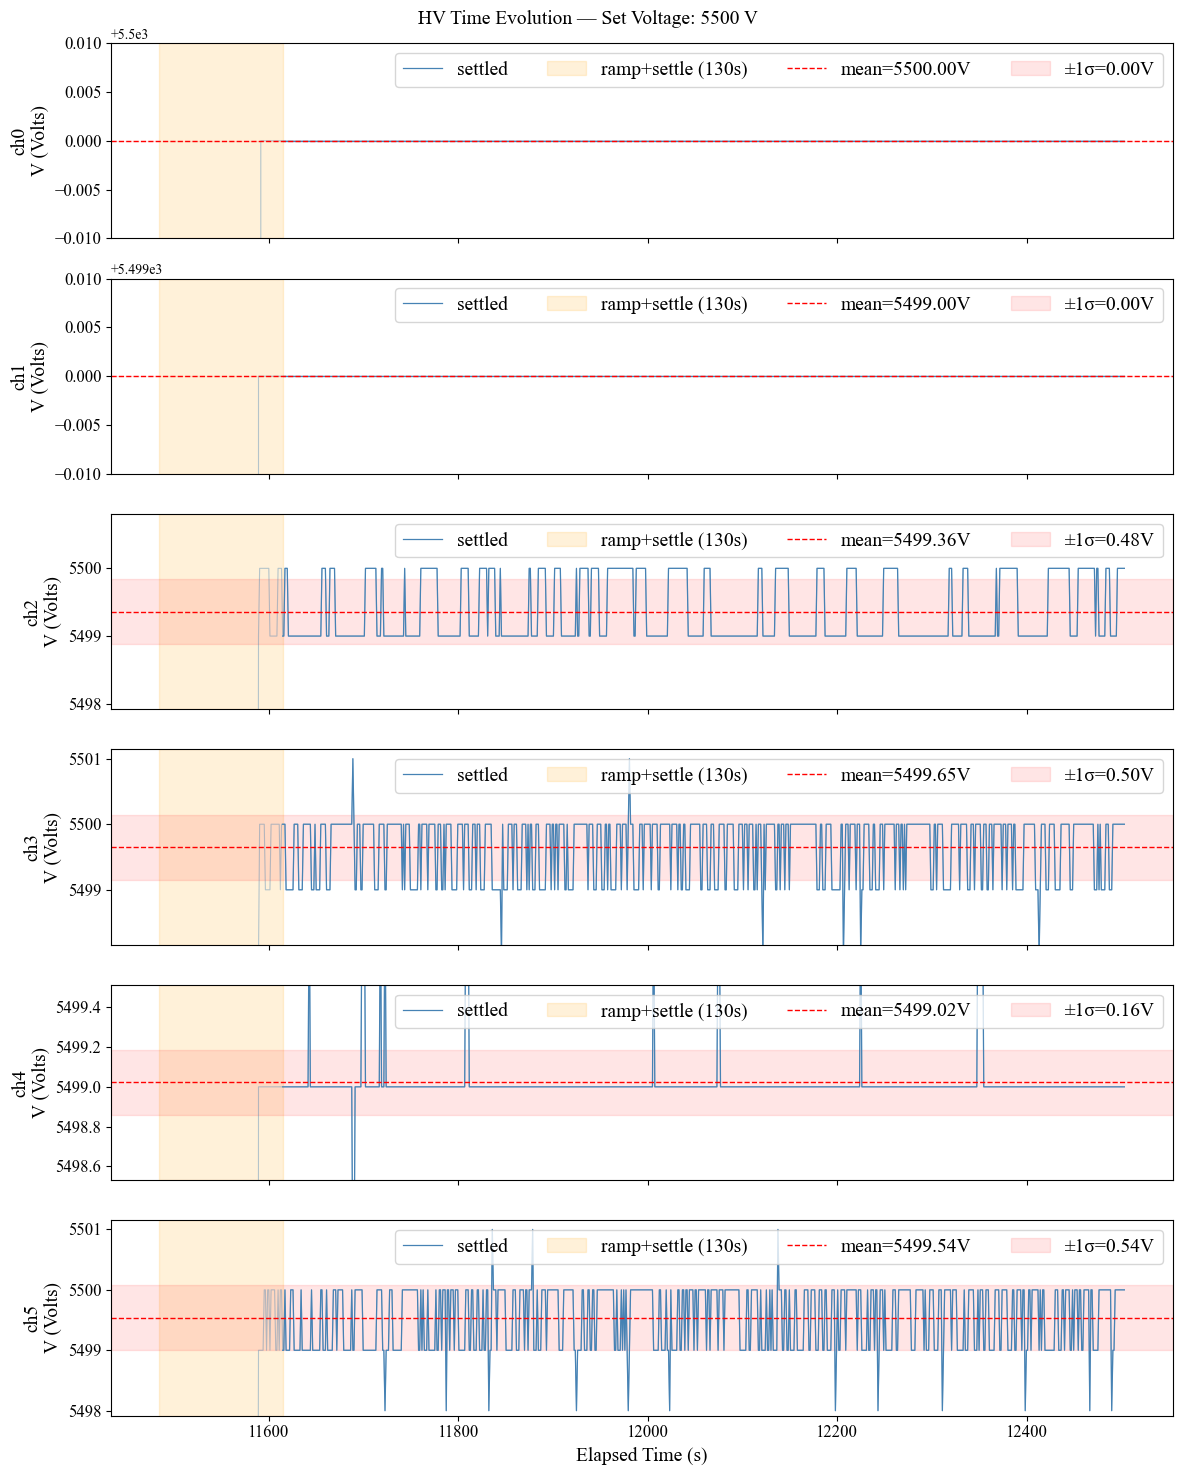

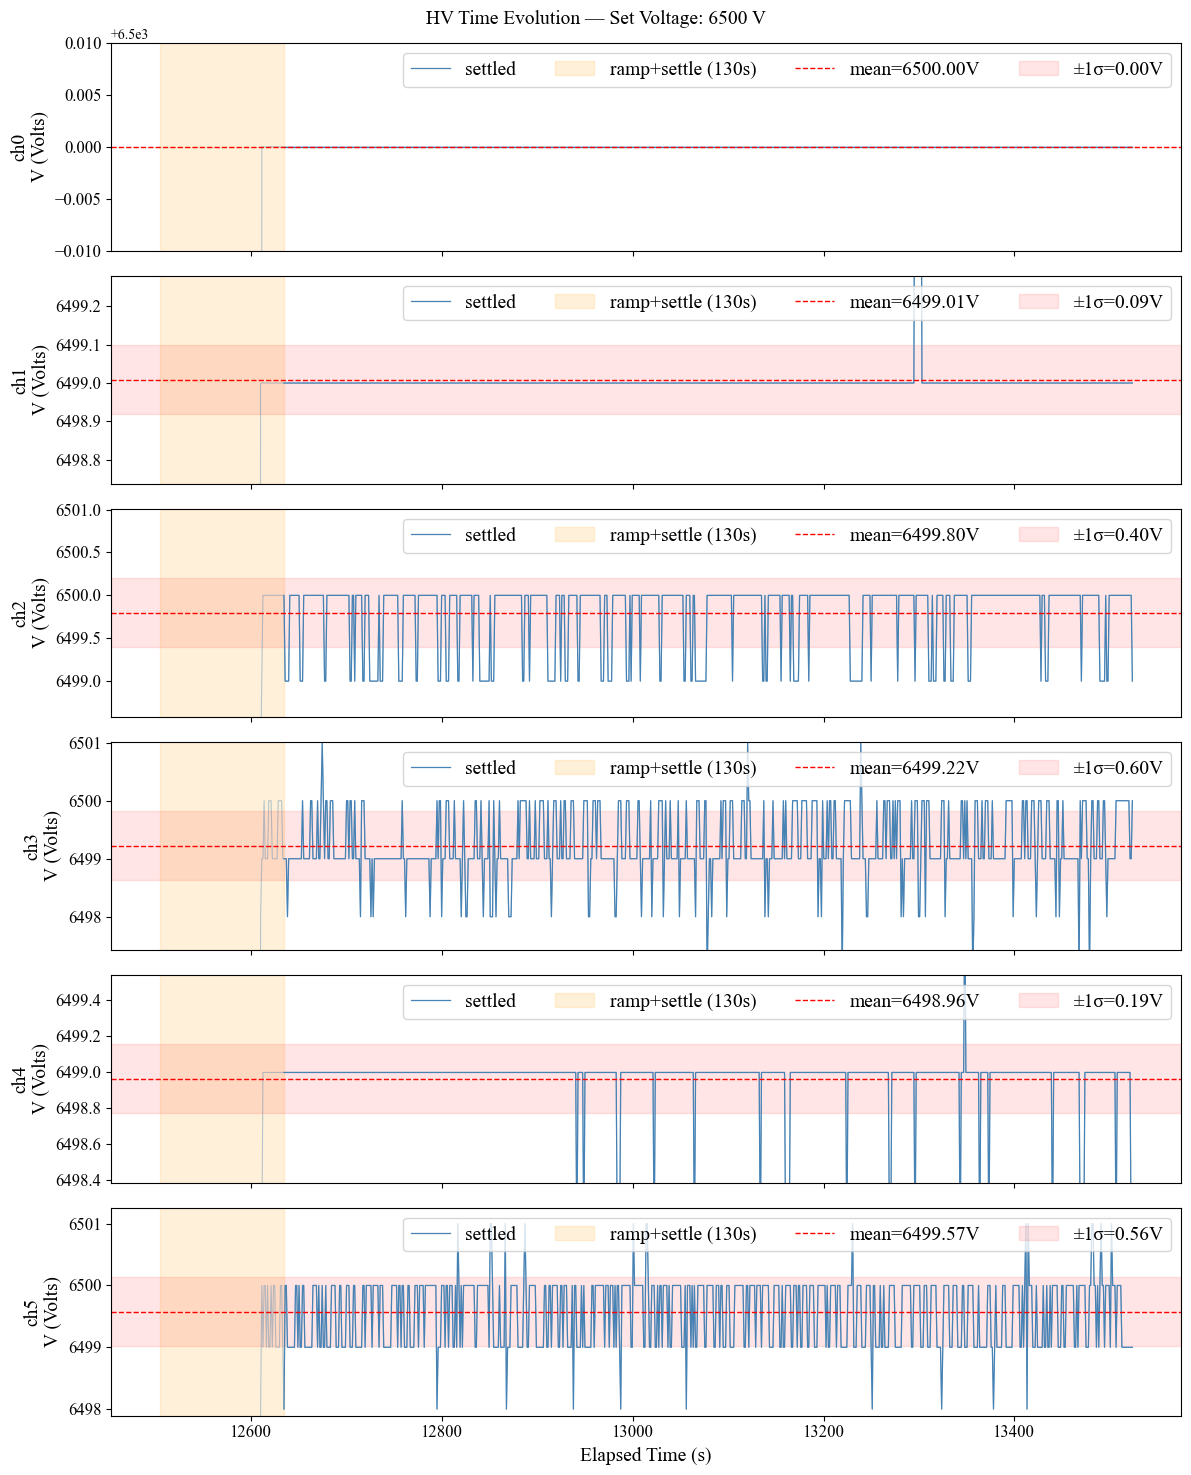

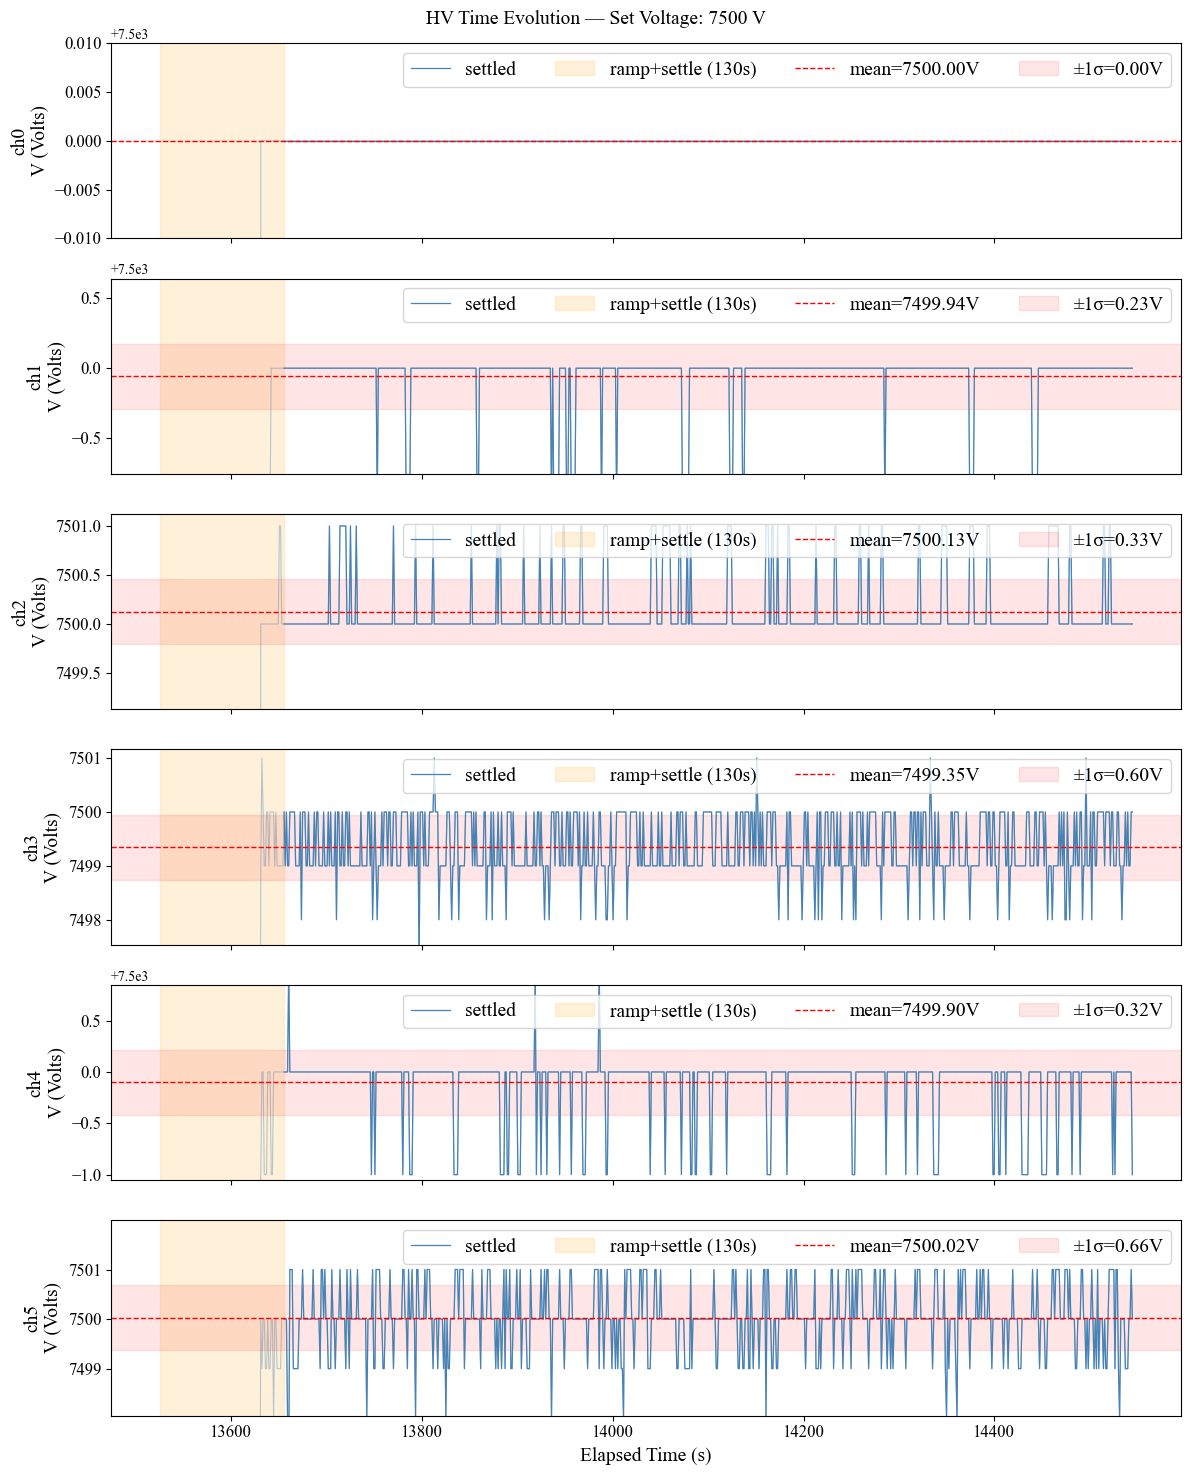

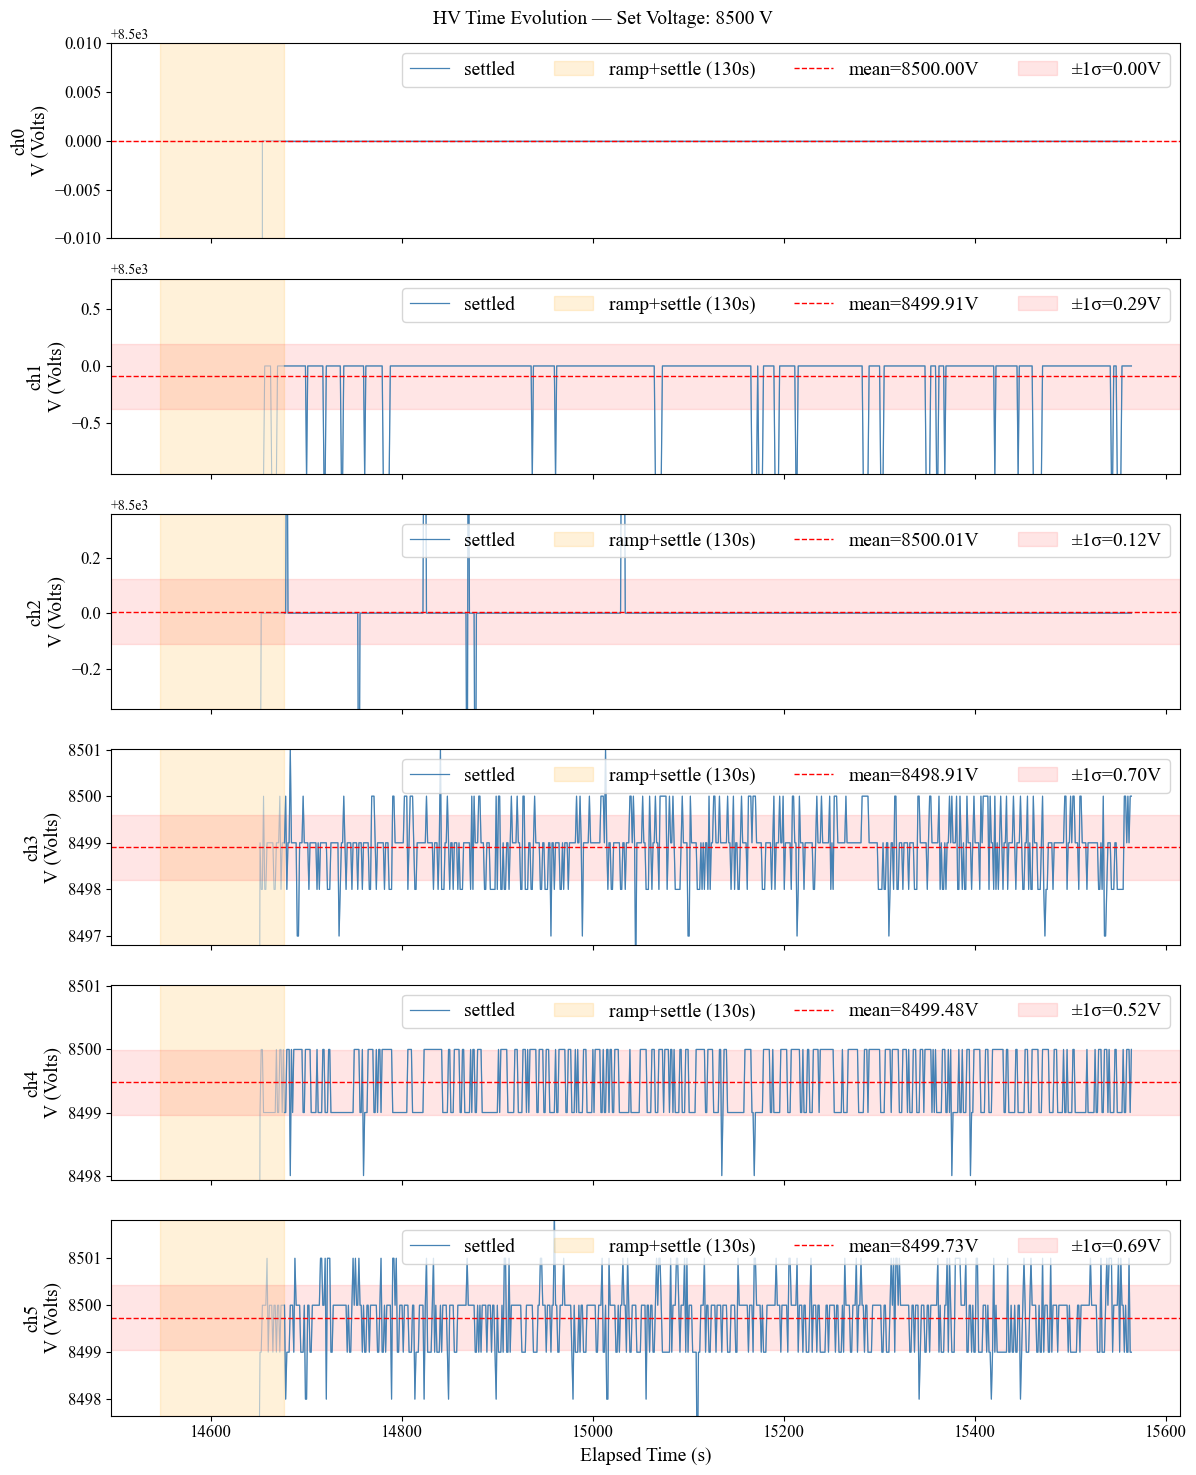

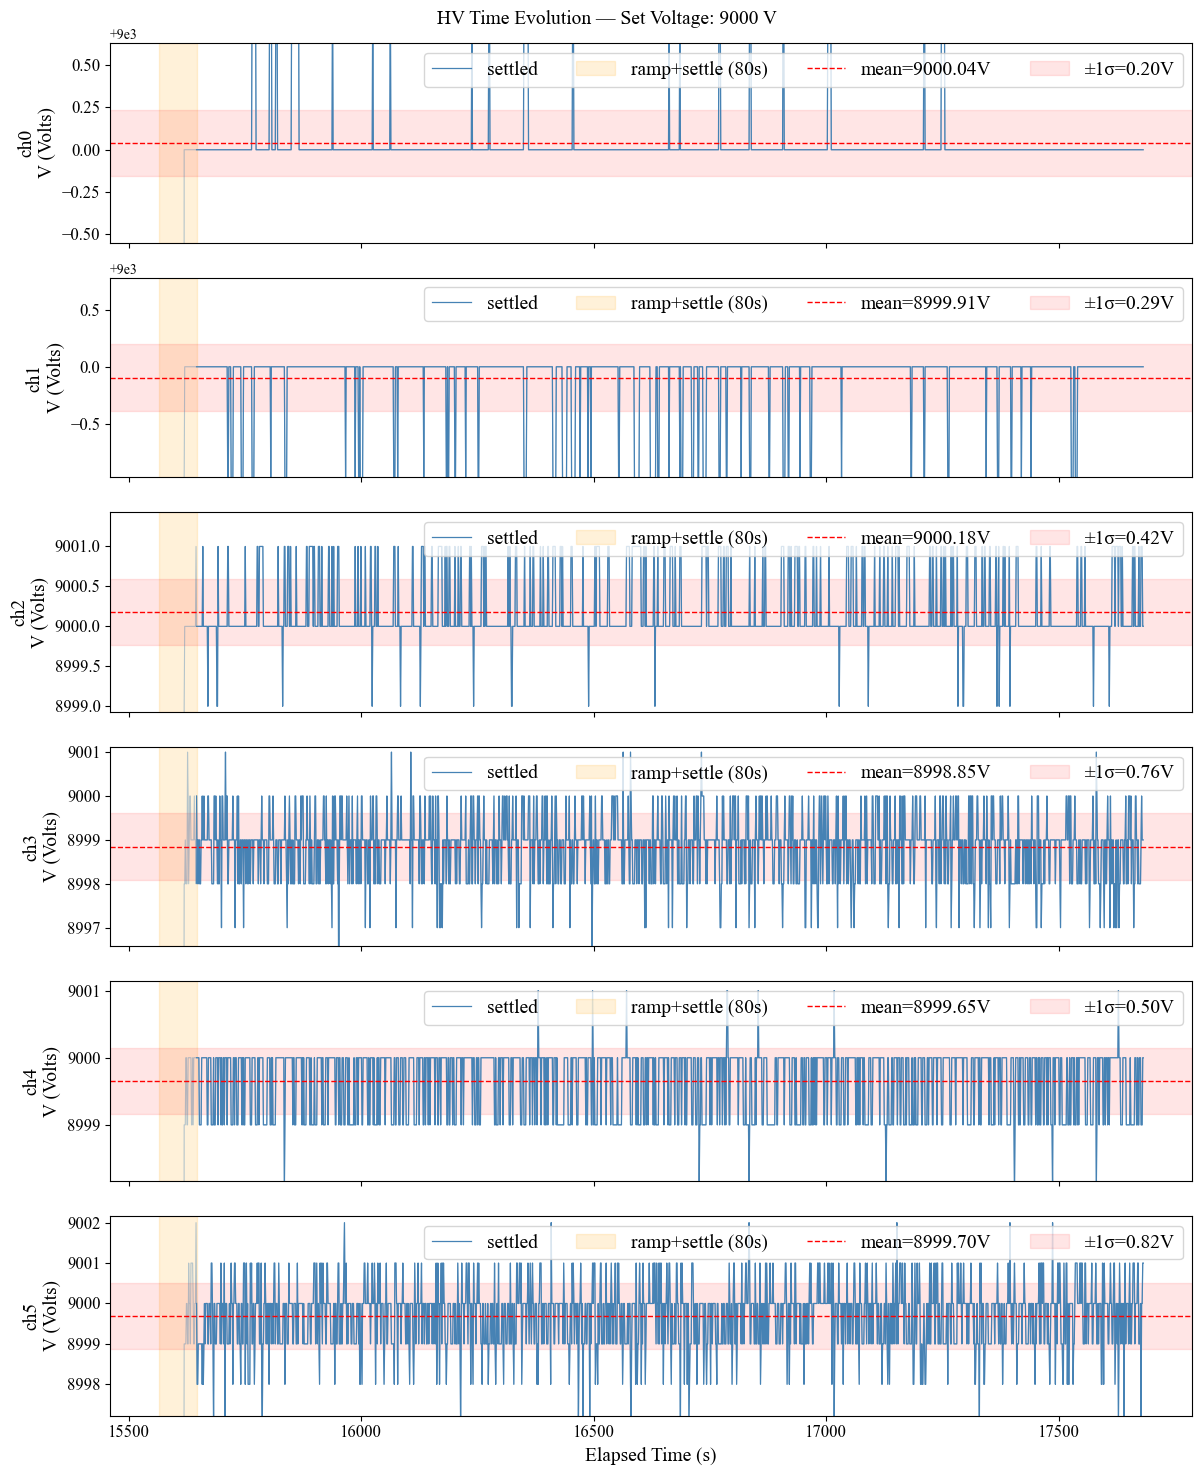

In [8]:
def plot_lightcurves_by_setv(df: pl.DataFrame, stability: dict, n_channels: int = N_CHANNELS):
    """
    One figure per unique set voltage.
    Multi-axis lightcurve: monitored voltage vs time for each active channel.
    Ramp + settle window marked as shaded region.
    """
    time_col = "Elapsed"

    all_setvs = sorted({
        setv
        for ch_stats in stability.values()
        for setv in ch_stats.keys()
    })

    for setv in all_setvs:
        active_chs = [
            f"ch{i}" for i in range(n_channels)
            if f"ch{i}" in stability and setv in stability[f"ch{i}"]
        ]
        if not active_chs:
            continue

        nrows = len(active_chs)
        fig, axes = plt.subplots(nrows, 1,
                                 figsize=(12, 2.5 * nrows),
                                 sharex=True,
                                 squeeze=False)
        fig.suptitle(f"HV Time Evolution — Set Voltage: {setv:.0f} V",
                     fontsize=14, fontweight="normal")

        for idx, ch in enumerate(active_chs):
            ax    = axes[idx][0]
            i     = int(ch.replace("ch", ""))
            stats = stability[ch][setv]

            setv_col   = f"ch{i}_setV"
            monv_col   = f"ch{i}_monV"
            status_col = f"ch{i}_status"

            # Pull the full segment for this channel at this setV (status on, setV match)
            seg = df.filter(
                (pl.col(status_col) == 1) &
                (pl.col(setv_col)   == setv)
            ).sort(time_col)

            t   = seg[time_col].to_numpy()
            hv  = seg[monv_col].to_numpy()

            # Recompute skip window boundaries
            t_start    = t[0]
            prior      = df.filter(
                (pl.col(status_col) == 1) &
                (pl.col(setv_col)   > 0)  &
                (pl.col(time_col)   < t_start)
            )
            prev_setv  = prior[setv_col][-1] if len(prior) > 0 else 0.0
            ramp_time  = abs(setv - prev_setv) / RAMP_RATE
            skip_time  = ramp_time + SETTLE_TIME
            t_settled  = t_start + skip_time

            # Full trace (ramp + settling) in muted color
            ax.plot(t, hv, color="steelblue", linewidth=0.8, alpha=0.4, label="_nolegend_")

            # Settled trace in solid color
            mask = t >= t_settled
            ax.plot(t[mask], hv[mask], color="steelblue", linewidth=0.9, label="settled")

            # Shaded exclusion window
            ax.axvspan(t_start, t_settled, color="orange", alpha=0.15, label=f"ramp+settle ({skip_time:.0f}s)")

            # Mean and ±1σ band over settled region
            ax.axhline(stats["mean"], color="red",   linestyle="--", linewidth=1.0, label=f'mean={stats["mean"]:.2f}V')
            ax.axhspan(stats["mean"] - stats["std"],
                       stats["mean"] + stats["std"],
                       color="red", alpha=0.10, label=f'±1σ={stats["std"]:.2f}V')

            ax.set_ylabel(f"{ch}\nV (Volts)", fontsize=14)
            ax.legend(fontsize=14, loc="upper right", ncol=4)
            ax.tick_params(labelsize=12)

            # Tight y-limits around settled data for visibility
            settled_hv = hv[mask]
            if len(settled_hv) > 0:
                margin = max(0.01, 3 * stats["std"])
                ax.set_ylim(stats["mean"] - margin, stats["mean"] + margin)

        axes[-1][0].set_xlabel("Elapsed Time (s)", fontsize=14)
        plt.tight_layout()
        #plt.savefig(f"hv_lightcurve_setV_{setv:.0f}V.png", dpi=150, bbox_inches="tight")
        plt.savefig(f"{root_dir}HVStabilityLightcuve_setV{setv:.0f}V.png", dpi=150, bbox_inches="tight")
        plt.show()

plot_lightcurves_by_setv(df, stability)

In [9]:
sup_title = rf"HV Stability for R$_L$ = ${RL_tag}$ $\Omega$"
file_ext = rf"RL_{RL_tag}Ohm"
csv_ext = filelist[5].split(".")[0]

plt.rcParams["font.family"] = "Times New Roman"

def plot_stability_vs_setv(stability: dict, n_channels: int = 8):
    """
    Two figures, each with two panels:
      Top Panel: Absolute Monitored Voltage vs SetV
      Bottom Panel: Residual (Monitored - SetV) vs SetV
      
      Fig 1: mean ± std dev
      Fig 2: mid ± range/2
    """
    colors = plt.cm.tab10.colors

    configs = [
        ("mean", "std", "Mean ± Std Dev", "±1σ"),
        ("mid", "half_range", "Midpoint ± Range/2", "±range/2"),
    ]

    for fig_idx, (center_key, spread_key, spread_title, spread_label) in enumerate(configs):
        # Create two subplots: ax1 for absolute, ax2 for residuals
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, 
                                       gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})
        
        # Track all setVs to draw reference lines later
        all_xs = set()

        for i in range(n_channels):
            ch = f"ch{i}"
            if ch not in stability or not stability[ch]:
                continue

            setvs = sorted(stability[ch].keys())
            centers = []
            spreads = []
            xs = []

            for setv in setvs:
                stats = stability[ch][setv]
                if fig_idx == 0:
                    center = stats["mean"]
                    spread = stats["std"]
                else:
                    center = (stats["max"] + stats["min"]) / 2
                    spread = stats["range"] / 2
                
                xs.append(setv)
                centers.append(center)
                spreads.append(spread)
                all_xs.add(setv)

            xs = np.array(xs)
            centers = np.array(centers)
            spreads = np.array(spreads)
            residuals = centers - xs  # Monitored - Expected
            
            color = colors[i % len(colors)]

            # --- Panel 1: Absolute Voltage ---
            ax1.plot(xs, centers, marker="o", markersize=4, linewidth=1, 
                     color=color, label=ch, alpha=0.7)
            ax1.fill_between(xs, centers - spreads, centers + spreads, 
                             color=color, alpha=0.1)

            # --- Panel 2: Residuals (Monitored - Expected) ---
            ax2.plot(xs, residuals, marker="s", markersize=4, linewidth=1, 
                     color=color, alpha=0.7)
            ax2.errorbar(xs, residuals, yerr=spreads, fmt="none", 
                         color=color, capsize=3, linewidth=0.8, alpha=0.6)
            ax2.fill_between(xs, residuals - spreads, residuals + spreads, 
                             color=color, alpha=0.1)
        
        # --- TICK AND LABEL CUSTOMIZATION ---
        for ax in [ax1, ax2]:
            # Set tick label size to 13
            ax.tick_params(axis='both', which='major', labelsize=13)
            ax.grid(True, linestyle="--", alpha=0.5)

        # Reference Lines
        if all_xs:
            v_min, v_max = min(all_xs), max(all_xs)
            # Ideal diagonal on top panel
            ax1.plot([v_min, v_max], [v_min, v_max], linestyle=":", 
                     color="gray", label="Ideal (monV = setV)", alpha=0.8)
            # Zero-line on residual panel
            ax2.axhline(0, linestyle="--", color="black", linewidth=1, alpha=0.5)

        # Formatting Top Panel
        ax1.set_ylabel("Monitored Voltage (V)", fontsize=14)
        ax1.set_title(f"{sup_title}: {spread_title}", fontsize=14, fontweight="normal")
        ax1.legend(fontsize=12, loc="upper left", ncol=2)
        ax1.grid(True, linestyle="--", alpha=0.5)

        # Formatting Bottom Panel
        ax2.set_xlabel("Set Voltage (V)", fontsize=14)
        ax2.set_ylabel(r"$\Delta$ (Mon - Set) [V]", fontsize=14)
        ax2.grid(True, linestyle="--", alpha=0.5)

        plt.tight_layout()
        
        # Save logic
        suffix = "mean_std" if fig_idx == 0 else "mid_range"
        plt.savefig(f"{root_dir}hv_stability_vs_setV_{suffix}_{file_ext}_{csv_ext}.png", dpi=150)
        plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_spread_vs_setv(stability: dict, n_channels: int = 8):
    """
    Two figures (one for Range/2, one for Std Dev).
    Each figure has two panels:
      Top: Absolute Spread (V)
      Bottom: Relative Spread (%)
    """
    colors = plt.cm.tab10.colors

    metrics = [
        ("half_range", f"{sup_title} Voltage Spread: ±Range/2 (Worst-case)", "±Range/2"),
        ("std",        f"{sup_title} Voltage Spread: ±Std Dev (RMS)",  "±Std Dev"),
    ]

    for fig_idx, (spread_key, fig_title, label_tag) in enumerate(metrics):
        # hspace=0 for seamless panels, sharex=True to align Set Voltage
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, 
                                       gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})

        for i in range(n_channels):
            ch = f"ch{i}"
            if ch not in stability or not stability[ch]: continue

            setvs = sorted(stability[ch].keys())
            v_spreads = []
            p_spreads = []
            xs = []

            for setv in setvs:
                stats = stability[ch][setv]
                # Calculate Absolute
                val = stats["range"]/2 if spread_key == "half_range" else stats["std"]
                
                # Calculate Percentage (avoiding 0V division)
                percent = (val / setv * 100) if setv > 0 else 0
                
                xs.append(setv)
                v_spreads.append(val)
                p_spreads.append(percent)

            xs, v_spreads, p_spreads = np.array(xs), np.array(v_spreads), np.array(p_spreads)
            color = colors[i % len(colors)]

            # --- Top Panel: Absolute (V) ---
            ax1.plot(xs, v_spreads, marker="o", markersize=5, linewidth=1.2, 
                     color=color, label=ch, alpha=0.8)
            
            # --- Bottom Panel: Percentage (%) ---
            ax2.plot(xs, p_spreads, marker="s", markersize=5, linewidth=1.2, 
                     color=color, alpha=0.8)

        # Global Formatting
        for ax in [ax1, ax2]:
            ax.tick_params(axis='both', which='major', labelsize=13)
            ax.grid(True, linestyle="--", alpha=0.5)

        # Panel 1 specific
        ax1.set_ylabel(f"{label_tag} (V)", fontsize=14)
        ax1.set_title(fig_title, fontsize=15, fontweight="normal", pad=20)
        ax1.legend(fontsize=12, loc="upper left", ncol=2)
        ax1.label_outer() # Hides the redundant x-axis numbers between panels

        # Panel 2 specific
        ax2.set_xlabel("Set Voltage (V)", fontsize=14)
        ax2.set_ylabel(f"{label_tag} (in %)", fontsize=14)
        ax2.set_ylim(bottom=0)

        plt.tight_layout()
        plt.savefig(f"{root_dir}hv_spread_vs_setV_{'range' if fig_idx == 0 else 'std'}_{file_ext}_{csv_ext}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

In [10]:
RLOAD = 477e6  # 10 GOhm in Ohms

def plot_current_vs_setv1(stability: dict, n_channels: int = N_CHANNELS):
    """
    Three current estimates plotted vs setV for all channels:
      1. I_expected = setV / Rload         (ideal Ohmic expectation)
      2. I_computed = monV_mean / Rload    (Ohmic estimate from actual voltage)
      3. I_measured = monI_mean            (true recorded current)
    All in nA. Color-coded by channel.
    """
    colors  = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(7, 6))

    for i in range(n_channels):
        ch = f"ch{i}"
        if ch not in stability or not stability[ch]:
            continue

        setvs       = sorted(stability[ch].keys())
        xs          = []
        i_expected  = []
        i_computed  = []
        i_measured  = []
        # print(f"Processing {ch} with setVs: {setvs}")

        for setv in setvs:
            stats = stability[ch][setv]
            xs.append(setv)
            i_expected.append((setv            / RLOAD) * 1e9)   # nA
            i_computed.append((stats["mean"]   / RLOAD) * 1e9)   # nA
            i_measured.append( stats["curr_mean"]       * 1e3)   # nA, assuming monI in uA
            # print(f"  setV={setv:.1f}V: I_expected={i_expected[-1]:.2f}nA, "
            #       f"I_computed={i_computed[-1]:.2f}nA, "
            #       f"I_measured={i_measured[-1]:.2f}nA")

        xs         = np.array(xs)
        i_expected = np.array(i_expected)
        i_computed = np.array(i_computed)
        i_measured = np.array(i_measured)
        color      = colors[i % len(colors)]

        # Ideal Ohmic line: setV / Rload (dashed)
        ax.plot(xs, i_expected,
                linestyle="--", linewidth=1.0,
                color='k', alpha=0.4,
                label=f"{ch} setV/R")

        # # Computed from monV: monV_mean / Rload (dotted)
        ax.plot(xs, i_computed,
                linestyle=":", linewidth=1.2,
                color=color, alpha=0.7,
                label=f"{ch} monV/R")

        # True measured current (solid)
        ax.plot(xs, i_measured,
                linestyle="-", marker="o", markersize=5,
                linewidth=1.2, color=color,
                label=f"{ch} Imeas")

        # Spread band on measured current
        i_std = np.array([stability[ch][setv]["curr_std"] * 1e3 for setv in setvs])
        ax.fill_between(xs,
                        i_measured - 0.5 * i_std,
                        i_measured + 0.5 * i_std,
                        color=color, alpha=0.10)
        # print(f"  {ch} current std dev (nA): {i_std}")

    ax.set_xlabel("Set Voltage (V)", fontsize=14)
    ax.set_ylabel("Current (nA)", fontsize=14)
    ax.set_title(f"Current vs Set Voltage  [R$_{{L}}$ = {RLOAD/1e6:.0f} MΩ]",
                 fontsize=14, fontweight="normal")
    
    ax.tick_params(labelsize=14)

    # Split legend into two columns: channels in col1, line styles in col2
    style_legend = [
        plt.Line2D([0], [0], linestyle=":", color="k", alpha=0.6, label="setV / R$_{load}$"),
        #plt.Line2D([0], [0], linestyle=":",  color="gray", alpha=0.8, label="monV / R$_{load}$"),
        #plt.Line2D([0], [0], linestyle="-",  color="gray", marker="o", markersize=4, label="I$_{meas}$"),
    ]
    ch_handles, _ = ax.get_legend_handles_labels()
    # Only keep one handle per channel (every 3rd starting from 2, the solid line)
    ch_legend = [ch_handles[i * 3 + 2] for i in range(n_channels)
                 if i * 3 + 2 < len(ch_handles)]
    ch_labels  = [f"ch{i}" for i in range(n_channels)
                  if f"ch{i}" in stability and stability[f"ch{i}"]]

    leg1 = ax.legend(ch_legend,  ch_labels,
                     fontsize=14, loc="upper left",   title="Channel")
    leg2 = ax.legend(style_legend, [h.get_label() for h in style_legend],
                     fontsize=14, loc="upper right")
    ax.add_artist(leg1)   # re-add first legend after second overwrites it

    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{root_dir}hv_current_vs_setV_{file_ext}_{csv_ext}.png", dpi=300, bbox_inches="tight")
    plt.show()

    #Modified current plot
    RLOAD = 477e6  # 477 MOhm in Ohms

def plot_current_vs_setv(stability: dict, n_channels: int = N_CHANNELS):
    """
    Top panel   : three current estimates vs setV (as before)
    Bottom panel: (I_measured - I_expected) and (I_computed - I_expected) vs setV
                  with ±0.5σ error bars on I_measured residual
    """
    std_dev_scale = 1.0  # Scale factor for error bars on residuals

    colors = plt.cm.tab10.colors
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, 
                                       gridspec_kw={'height_ratios': [3, 2], 'hspace': 0})

    for i in range(n_channels):
        ch = f"ch{i}"
        if ch not in stability or not stability[ch]:
            continue

        setvs      = sorted(stability[ch].keys())
        xs         = []
        i_expected = []
        i_computed = []
        i_measured = []
        i_std_arr  = []

        for setv in setvs:
            stats = stability[ch][setv]
            xs.append(setv)
            i_expected.append((setv          / RLOAD) * 1e9)   # nA
            i_computed.append((stats["mean"] / RLOAD) * 1e9)   # nA
            i_measured.append( stats["curr_mean"]     * 1e3)   # µA → nA
            i_std_arr.append(  stats["curr_std"]      * 1e3)   # µA → nA

        xs         = np.array(xs)
        i_expected = np.array(i_expected)
        i_computed = np.array(i_computed)
        i_measured = np.array(i_measured)
        i_std_arr  = np.array(i_std_arr)
        color      = colors[i % len(colors)]

        # ── Top panel ────────────────────────────────────────────────
        ax_top.plot(xs, i_expected,
                    linestyle="--", linewidth=1.0,
                    color="k", alpha=0.4,
                    label=f"{ch} setV/R")

        ax_top.plot(xs, i_computed,
                    linestyle=":", linewidth=1.2,
                    color=color, alpha=0.7,
                    label=f"{ch} monV/R")

        ax_top.plot(xs, i_measured,
                    linestyle="-", marker="o", markersize=5,
                    linewidth=1.2, color=color,
                    label=f"{ch} Imeas")

        ax_top.fill_between(xs,
                            i_measured - 1.0 * i_std_arr,
                            i_measured + 1.0 * i_std_arr,
                            color=color, alpha=0.10)

        # ── Bottom panel: residuals ───────────────────────────────────
        res_meas = i_measured - i_expected   # true measured − ideal
        # res_comp = i_computed - i_expected   # monV/R − ideal

        # monV/R residual (dotted, no error bar — deterministic from mean)
        # ax_bot.plot(xs, res_comp,
        #             linestyle=":", linewidth=1.2,
        #             color=color, alpha=0.7,
        #             label=f"{ch} monV/R − exp")

        # I_measured residual (solid + error bars)
        ax_bot.errorbar(xs, res_meas,
                        yerr= i_std_arr,
                        linestyle="-", marker="o", markersize=5,
                        linewidth=1.2, color=color,
                        capsize=3, capthick=0.8, elinewidth=0.8,
                        label=f"{ch} Imeas − exp")

        ax_bot.fill_between(xs,
                            res_meas - 1.0 * i_std_arr,
                            res_meas + 1.0 * i_std_arr,
                            color=color, alpha=0.10)

    # Zero reference line on residual panel
    ax_bot.axhline(0, color="k", linestyle="--", linewidth=0.8, alpha=0.5)

    # ── Labels and formatting ─────────────────────────────────────────
    ax_top.set_ylabel("Current (nA)", fontsize=14)
    ax_top.set_title(f"Current vs Set Voltage  [R$_{{L}}$ = {RLOAD/1e6:.0f} MΩ]",
                     fontsize=14, fontweight="normal")
    ax_top.tick_params(labelsize=14)
    ax_top.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    ax_bot.set_xlabel("Set Voltage (V)", fontsize=14)
    ax_bot.set_ylabel("$\\Delta I$ = $I_{mon}$ − setV / R$_{L}$ (nA)", fontsize=14)
    ax_bot.tick_params(labelsize=14)
    ax_bot.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # ── Legends ───────────────────────────────────────────────────────
    style_legend = [
        plt.Line2D([0], [0], linestyle="--", color="k",    alpha=0.5, label="setV / R$_{L}$"),
        # plt.Line2D([0], [0], linestyle=":",  color="gray", alpha=0.8, label="monV / R$_{L}$"),
        # plt.Line2D([0], [0], linestyle="-",  color="gray", marker="o", markersize=4, label="I$_{meas}$"),
    ]
    ch_handles, _ = ax_top.get_legend_handles_labels()
    # Solid line handle is every 3rd entry starting at index 2
    ch_legend = [ch_handles[i * 3 + 2] for i in range(n_channels)
                 if i * 3 + 2 < len(ch_handles)]
    ch_labels  = [f"ch{i}" for i in range(n_channels)
                  if f"ch{i}" in stability and stability[f"ch{i}"]]

    leg1 = ax_top.legend(ch_legend, ch_labels,
                         fontsize=11, loc="upper left", title="Channel")
    leg2 = ax_top.legend(style_legend, [h.get_label() for h in style_legend],
                         fontsize=11, loc="lower right", title="Expected")
    ax_top.add_artist(leg1)

    # # Bottom panel legend: just channel colors, one entry per channel
    # bot_handles, bot_labels = ax_bot.get_legend_handles_labels()
    # # Solid marker handles are every 2nd entry starting at index 1
    # bot_ch_legend = [bot_handles[i * 2 + 1] for i in range(n_channels)
    #                  if i * 2 + 1 < len(bot_handles)]
    # ax_bot.legend(bot_ch_legend, ch_labels,
    #               fontsize=11, loc="best", title="Channel")

    # plt.savefig(f"{root_dir}hv_current_vs_setV_{file_ext}_{csv_ext}.png",
    #             dpi=300, bbox_inches="tight")
    plt.savefig(f"{root_dir}hv_current_vs_setV_{file_ext}_{csv_ext}.png", dpi=300, bbox_inches="tight")
    plt.show()

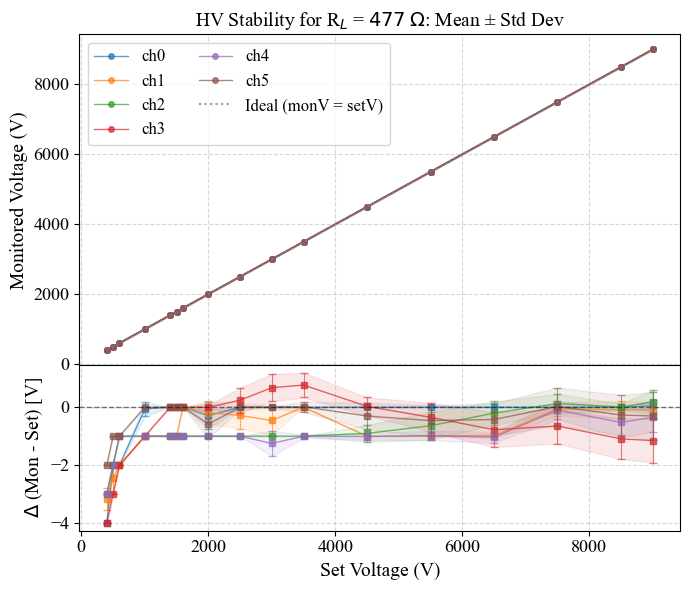

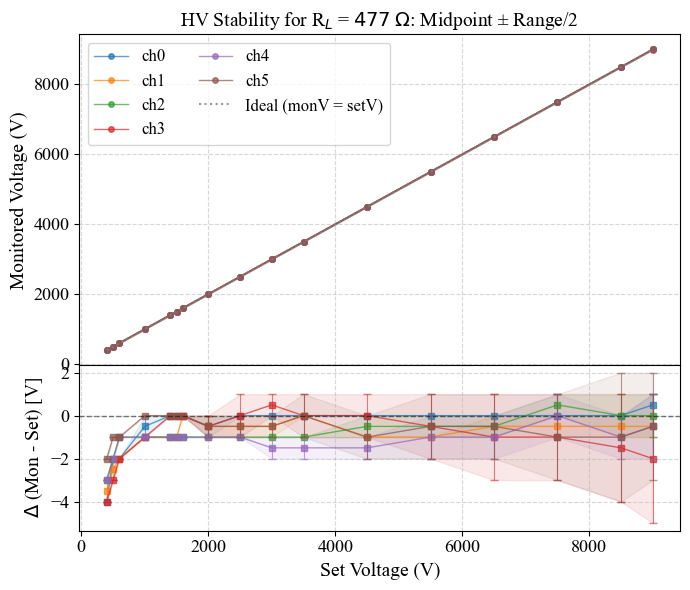

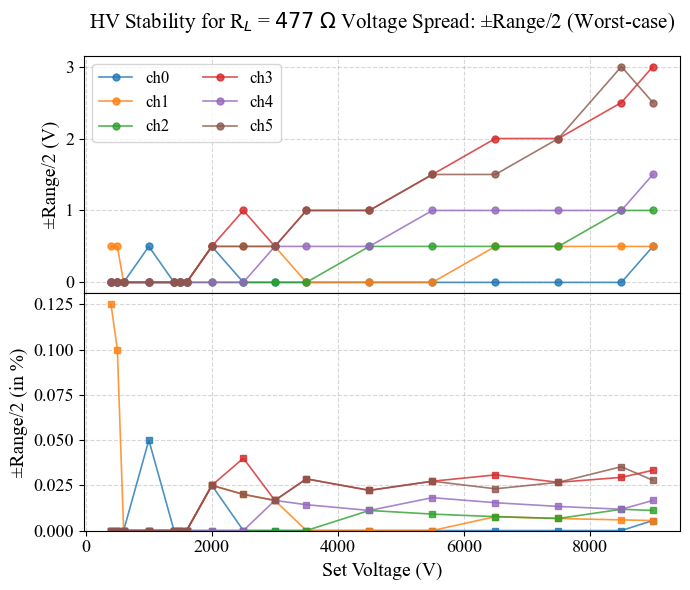

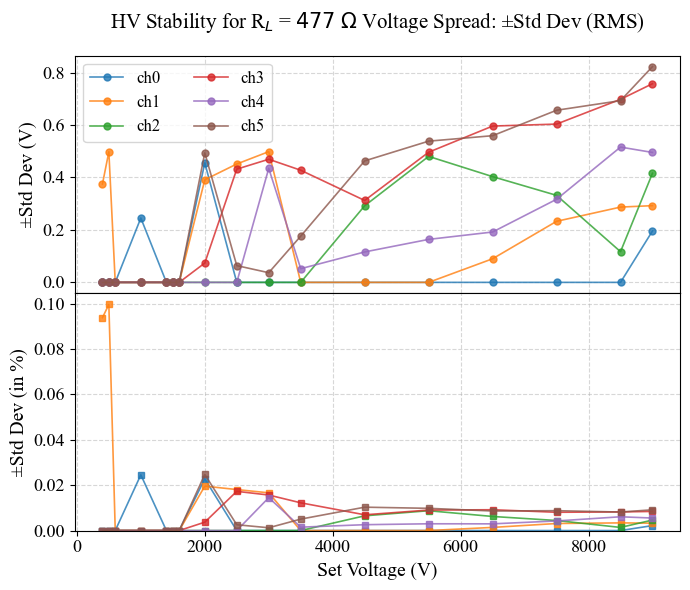

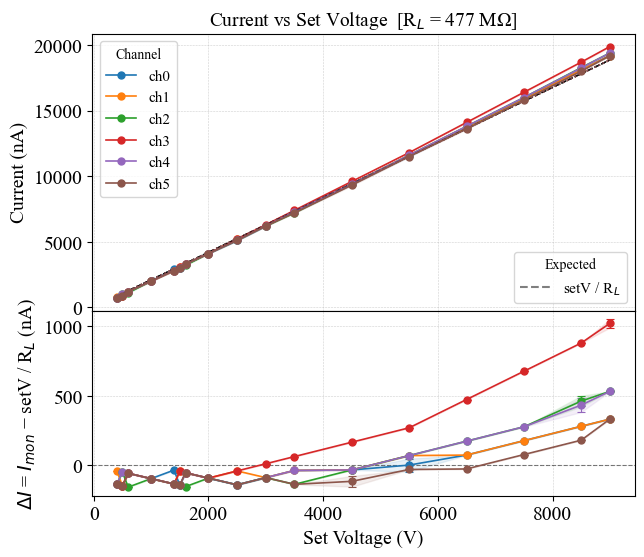

In [11]:
stability = {}
for i in range(N_CHANNELS):
    ch_stats = get_channel_stability(df, i)
    if ch_stats:
        stability[f"ch{i}"] = ch_stats

# plot_stability_by_setv(stability)
# plot_lightcurves_by_setv(df, stability)
plot_stability_vs_setv(stability)
plot_spread_vs_setv(stability)
plot_current_vs_setv(stability)

In [13]:
# Print measured current
ch = 'ch1'
setv = 3000
stats = stability[ch][setv] #Ch=1, setv=3000

stats


{'mean': 2999.5421195652175,
 'std': 0.49856159558899243,
 'min': 2999.0,
 'max': 3000.0,
 'range': 1.0,
 'offset': -0.45788043478250984,
 'hv_settled': shape: (736,)
 Series: 'ch1_monV' [f64]
 [
 	2999.0
 	2999.0
 	2999.0
 	2999.0
 	2999.0
 	…
 	3000.0
 	3000.0
 	3000.0
 	3000.0
 	3000.0
 ],
 'curr_settled': shape: (736,)
 Series: 'ch1_monI' [f64]
 [
 	6.2
 	6.2
 	6.2
 	6.2
 	6.2
 	…
 	6.2
 	6.2
 	6.2
 	6.2
 	6.2
 ],
 'curr_mean': 6.199999809265137,
 'curr_std': 0.0,
 'curr_range': 0.0,
 'skip_time': 80.0,
 't_settled': datetime.datetime(2026, 4, 29, 14, 48, 24),
 't_start': datetime.datetime(2026, 4, 29, 14, 47, 4)}

In [ ]:
from scipy.signal      import welch
from scipy.interpolate import interp1d
from astropy.timeseries import LombScargle

def diagnose_sampling(df: pl.DataFrame) -> float:
    """Check timestamp regularity. Returns median fs."""
    dt = (df["Timestamp"]
          .diff()
          .drop_nulls()
          .dt.total_milliseconds() / 1000.0)

    dt_np  = dt.to_numpy()
    dt_med = float(np.median(dt_np))
    fs     = 1.0 / dt_med

    print(f"Sample interval stats:")
    print(f"  median : {dt_med:.3f} s  →  fs = {fs:.3f} Hz")
    print(f"  mean   : {float(dt.mean()):.3f} s")
    print(f"  std    : {float(dt.std()):.4f} s")
    print(f"  min    : {float(dt.min()):.3f} s")
    print(f"  max    : {float(dt.max()):.3f} s")
    print(f"  gaps>2x median: {int((dt > 2 * dt_med).sum())} occurrences")

    fig, axes = plt.subplots(2, 1, figsize=(12, 4))
    axes[0].plot(dt_np, linewidth=0.6, color="steelblue")
    axes[0].axhline(dt_med, color="red", linestyle="--", linewidth=0.8, label="median")
    axes[0].set_ylabel("Δt (s)")
    axes[0].set_xlabel("Sample index")
    axes[0].set_title("Timestamp interval time series")
    axes[0].legend(fontsize=8)

    axes[1].hist(dt_np, bins=50, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("Δt (s)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Timestamp interval distribution")

    plt.tight_layout()
    #plt.savefig(f"{root_dir}sampling_diagnosis.png", dpi=150, bbox_inches="tight")
    plt.show()
    return fs


def compute_psd(t: np.ndarray, x: np.ndarray) -> tuple:
    """
    Auto-select PSD method based on timestamp regularity.
    Returns (freqs, psd, method_used).
    """
    dt      = np.diff(t)
    dt_med  = np.median(dt)
    jitter  = np.std(dt) / dt_med
    has_gaps = np.any(dt > 5 * dt_med)

    if has_gaps:
        method = "lomb"
    elif jitter > 0.05:
        method = "interp_welch"
    else:
        method = "welch"

    if method == "welch":
        fs         = 1.0 / dt_med
        nperseg    = min(256, len(x) // 4)
        freqs, psd = welch(x, fs=fs, window="hann",
                           nperseg=nperseg, scaling="density")

    elif method == "interp_welch":
        fs          = 1.0 / dt_med
        t_uniform   = np.arange(t[0], t[-1], dt_med)
        x_uniform   = interp1d(t, x, kind="linear",
                               bounds_error=False,
                               fill_value="extrapolate")(t_uniform)
        nperseg     = min(256, len(x_uniform) // 4)
        freqs, psd  = welch(x_uniform, fs=fs, window="hann",
                            nperseg=nperseg, scaling="density")

    elif method == "lomb":
        ls    = LombScargle(t, x)
        fs_ny = 1.0 / (2 * dt_med)
        freqs = np.linspace(1.0 / (t[-1] - t[0]), fs_ny, 1000)
        psd   = ls.power(freqs, normalization="psd")

    return freqs, psd, method, jitter, has_gaps


def plot_psd_by_setv(df: pl.DataFrame, stability: dict,
                     n_channels: int = N_CHANNELS):
    """
    One figure per unique set voltage.
    Uses t_settled and t_start already stored in stability dict.
    Time array built from Timestamp → seconds for compute_psd.
    """
    colors    = plt.cm.tab10.colors
    all_setvs = sorted({
        setv
        for ch_stats in stability.values()
        for setv in ch_stats.keys()
    })

    for setv in all_setvs:
        active_chs = [
            f"ch{i}" for i in range(n_channels)
            if f"ch{i}" in stability and setv in stability[f"ch{i}"]
        ]
        if not active_chs:
            continue

        ncols = min(3, len(active_chs))
        nrows = int(np.ceil(len(active_chs) / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5 * ncols, 4 * nrows),
                                 squeeze=False)
        fig.suptitle(f"Power Spectral Density — Set Voltage: {setv:.0f} V",
                     fontsize=14, fontweight="bold")

        for idx, ch in enumerate(active_chs):
            ax    = axes[idx // ncols][idx % ncols]
            stats = stability[ch][setv]
            color = colors[int(ch.replace("ch", "")) % len(colors)]

            i          = int(ch.replace("ch", ""))
            setv_col   = f"ch{i}_setV"
            monv_col   = f"ch{i}_monV"
            status_col = f"ch{i}_status"

            # Use t_settled stored during stability construction
            seg = df.filter(
                (pl.col(status_col)  == 1) &
                (pl.col(setv_col)    == setv) &
                (pl.col("Timestamp") >= stats["t_settled"])
            ).sort("Timestamp")

            if len(seg) < 16:
                ax.set_title(f"{ch} — too few samples ({len(seg)})")
                continue

            # Convert Timestamp → elapsed seconds from segment start
            t = (seg["Timestamp"] - seg["Timestamp"][0]
                 ).dt.total_milliseconds().to_numpy() / 1000.0
            x = seg[monv_col].to_numpy()

            freqs, psd, method_used, jitter, has_gaps = compute_psd(t, x)
            psd_db = 10 * np.log10(psd + 1e-30)

            ax.plot(freqs, psd_db, color=color, linewidth=0.9)

            # White noise floor from upper half of spectrum
            noise_floor = np.median(psd_db[len(psd_db) // 2:])
            ax.axhline(noise_floor, color="gray", linestyle="--",
                       linewidth=0.8,
                       label=f"floor: {noise_floor:.1f} dBV²/Hz")

            # Mains lines only if within Nyquist
            fs_ny = 1.0 / (2 * np.median(np.diff(t)))
            for f_mains, lbl in [(50, "50 Hz"), (100, "100 Hz")]:
                if f_mains < fs_ny:
                    ax.axvline(f_mains, color="red", linestyle=":",
                               linewidth=0.8, alpha=0.7, label=lbl)

            # Dominant frequency excluding DC bin
            peak_idx  = np.argmax(psd[1:]) + 1
            peak_freq = freqs[peak_idx]
            peak_db   = psd_db[peak_idx]
            ax.annotate(f"{peak_freq:.4f} Hz",
                        xy=(peak_freq, peak_db),
                        xytext=(8, -10), textcoords="offset points",
                        fontsize=7, color=color,
                        arrowprops=dict(arrowstyle="->", lw=0.6, color=color))

            #ax.set_xscale("log")
            ax.set_xlabel("Frequency (Hz)", fontsize=9)
            ax.set_ylabel("PSD (dBV²/Hz)", fontsize=9)
            ax.set_title(
                f"{ch}  [{method_used}]  n={len(seg)}\n"
                f"jitter={jitter:.2%}  gaps={has_gaps}",
                fontsize=8)
            ax.legend(fontsize=7, loc="upper right")
            ax.grid(True, which="both", linestyle="--", linewidth=0.3, alpha=0.5)

        for idx in range(len(active_chs), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)

        plt.tight_layout()
        #plt.savefig(f"{root_dir}psd_setV_{setv:.0f}V.png", dpi=150, bbox_inches="tight")
        plt.show()

In [14]:
fs = diagnose_sampling(df)      # always run first — tells you which PSD method will be chosen
plot_psd_by_setv(df, stability)

NameError: name 'diagnose_sampling' is not defined